# Data Analysis
## Participant-Group Differences in TTU and DOU Across Tasks, and Task Properties 
todo concept 

In [1]:
#TODO: 
# language = EN everywhere,
# formatting 

# Set-up 

In [2]:
library(nparLD)
library(dplyr)
library(tidyr)
library(ggplot2)

library(psych)   # for ICC
library(irr)     # for ICC alternative
library(blandr) # for Bland‑Altman


Attache Paket: ‘dplyr’


Die folgenden Objekte sind maskiert von ‘package:stats’:

    filter, lag


Die folgenden Objekte sind maskiert von ‘package:base’:

    intersect, setdiff, setequal, union



Attache Paket: ‘psych’


Die folgenden Objekte sind maskiert von ‘package:ggplot2’:

    %+%, alpha


Lade nötiges Paket: lpSolve



In [3]:
html_print <- function(text) {
  IRdisplay::display_html(text)
}

bold <- function(text) {
  paste0("<b>", text, "</b>")
}

italic <- function(text) {
  paste0("<i>", text, "</i>")
}

heading <- function(text, level = 2) {
  IRdisplay::display_html(
    paste0("<h", level, ">", text, "</h", level, ">")
  )
}

line <- function() {
  IRdisplay::display_html("<hr>")
}

Global significance level:

In [4]:
alpha <- 0.05

Loading data from csv (saved via py):

In [5]:
dat <- read.csv(
  "study_data.csv",
  sep = ";",
  header = TRUE,
  check.names = FALSE,# keep column names identical
  stringsAsFactors = FALSE
)

In [6]:
# Python-Listenrepräsentation als R-Vektor einlesen:
# "['COMP', 'CELL', 'VAL']" -> c("COMP", "CELL", "VAL")
parse_list_column <- function(x) {
  
  if (is.na(x)) {
    return(character(0))
  }
  
  x <- trimws(x)
  
  # Leere Listen / leere Werte
  if (x %in% c("", "[]", "NA", "None", "NULL")) {
    return(character(0))
  }
  
  # Alle eckigen Klammern entfernen
  x <- gsub("[", "", x, fixed = TRUE)
  x <- gsub("]", "", x, fixed = TRUE)
  x <- trimws(x)
  
  if (!nzchar(x)) {
    return(character(0))
  }
  
  # Am Komma trennen
  values <- strsplit(x, ",", fixed = TRUE)[[1]]
  
  # Leerzeichen und äußere Anführungszeichen entfernen
  values <- trimws(values)
  values <- gsub("^['\"]|['\"]$", "", values)
  
  # Leere Einträge entfernen
  values[nzchar(values)]
}


# Assert: 
stopifnot(
  identical(
    parse_list_column("['COMP', 'CELL', 'VAL', 'BACK', 'ON']"),
    c("COMP", "CELL", "VAL", "BACK", "ON")
  )
)

In [7]:
# Eigene Importfunktion
read_study_data <- function(path) {
  
  dat <- read.csv(
      "study_data.csv",
      sep = ";",
      header = TRUE,
      check.names = FALSE,# keep column names identical
      stringsAsFactors = FALSE,
      na.strings = c("", "NA")
  )
  
  # Diese Spalten enthalten Listen
  list_columns <- c(
    "structural_aspects",
    "operation_type",
    "operand_type",
    "result_type",
    "Ref_direction",
    "Ref_dispersion"
  )
  
  # Nur vorhandene Spalten bearbeiten
  list_columns <- intersect(list_columns, names(dat))
  
  for (column in list_columns) {
    dat[[column]] <- lapply(dat[[column]], parse_list_column)
  }
  
  dat
}


In [8]:
dat <- read_study_data("study_data.csv")

In [9]:
head(dat)

,participant,task_id,group,TTU,DOU,structural_aspects,video_length_in_s,timestamp_where_participant_realizes,TTU_second_coder,DOU_second_coder,timestamp_where_participant_realizes_second_coder
,<chr>,<int>,<chr>,<dbl>,<dbl>,<list>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,p01,1,Formula construction,17,1.0,"COMP, CELL, VAL , BACK, ON",12,130,66,1,179
2,p31,1,Formula construction,23,0.6,"COMP, CELL, VAL , BACK, ON",12,45,96,1,117
3,p34,1,Formula construction,14,1.0,"COMP, CELL, VAL , BACK, ON",12,14,18,1,18
4,p33,1,Formula construction,28,1.0,"COMP, CELL, VAL , BACK, ON",12,49,33,1,54
5,p26,1,Formula construction,92,0.6,"COMP, CELL, VAL , BACK, ON",12,128,89,1,125
6,p21,1,Formula construction,33,1.0,"COMP, CELL, VAL , BACK, ON",12,64,36,1,67


In [10]:
# Faktoren und Reihenfolge vorbereiten
dat <- dat %>%
  mutate(
    participant = factor(participant),
    group = factor(group),
    task_id = factor(task_id, levels = 1:17),
    TTU = as.numeric(TTU),
    DOU = as.numeric(DOU)
  )

In [11]:
plot_by_group_and_task <- function(
  data,
  measure,
  pdf_file = NULL,
  y_break = NULL,
  break_scale = 1 / 10,
  width = 10,
  height = 5
) {

  # --------------------------------------------------------------------------
  # Checks
  # --------------------------------------------------------------------------

  required_cols <- c("task_id", "group", measure)
  missing_cols <- setdiff(required_cols, names(data))

  if (length(missing_cols) > 0) {
    stop("Missing column(s): ", paste(missing_cols, collapse = ", "))
  }

  if (!is.numeric(data[[measure]])) {
    stop(sprintf("'%s' must be numeric.", measure))
  }

  if (!is.null(y_break)) {
    if (
      length(y_break) != 2 ||
      !is.numeric(y_break) ||
      any(!is.finite(y_break)) ||
      y_break[1] >= y_break[2]
    ) {
      stop(
        "y_break must contain two increasing numeric values, ",
        "e.g. c(300, 2220)."
      )
    }
  }

  # --------------------------------------------------------------------------
  # Prepare data
  # --------------------------------------------------------------------------

  plot_data <- data[
    is.finite(data[[measure]]) &
      !is.na(data$task_id) &
      !is.na(data$group),
    ,
    drop = FALSE
  ]

  if (nrow(plot_data) == 0) {
    stop("No valid observations available for plotting.")
  }

  # Preserve original ordering in the data
  task_levels <- unique(as.character(plot_data$task_id))
  group_levels <- unique(as.character(plot_data$group))

  plot_data$task_id <- factor(
    plot_data$task_id,
    levels = task_levels
  )

  plot_data$group <- factor(
    plot_data$group,
    levels = group_levels
  )

  n_groups <- length(group_levels)
  n_tasks <- length(task_levels)

  # Requested y-axis label
  y_label <- if (measure == "TTU") {
    "TTU [s]"
  } else {
    "DOU [ ]"
  }

  # Group colours
  group_colours <- grDevices::hcl.colors(
    n = n_groups,
    palette = "Dark 3"
  )
  names(group_colours) <- group_levels

  # Default output filename
  if (is.null(pdf_file)) {
    safe_measure <- gsub("[^A-Za-z0-9_-]", "_", measure)
    pdf_file <- paste0(safe_measure, "_by_group_and_task.pdf")
  }

  # --------------------------------------------------------------------------
  # Facet-specific x-axis variable
  #
  # Separate internal x-axis levels are required so that the middle facet can
  # use labels 2, 4, 6, ... while the other facets use labels 1, 3, 5, ...
  # --------------------------------------------------------------------------

  make_task_key <- function(group, task) {
    paste(
      as.character(group),
      as.character(task),
      sep = "\r"
    )
  }

  task_plot_levels <- unlist(
    lapply(
      group_levels,
      function(current_group) {
        make_task_key(current_group, task_levels)
      }
    ),
    use.names = FALSE
  )

  plot_data$task_id_plot <- factor(
    make_task_key(
      plot_data$group,
      plot_data$task_id
    ),
    levels = task_plot_levels
  )

  # --------------------------------------------------------------------------
  # X-axis labels
  #
  # The middle facet labels positions 2, 4, 6, ...
  # All other facets label positions 1, 3, 5, ...
  #
  # All labels reserve three lines. This prevents vertical movement.
  # "Task" is shown below the labelled tick nearest to the centre.
  # --------------------------------------------------------------------------

  middle_group_index <- ceiling(n_groups / 2)

  x_axis_labels <- stats::setNames(
    rep("\n\n ", length(task_plot_levels)),
    task_plot_levels
  )

  for (group_index in seq_along(group_levels)) {

    current_group <- group_levels[group_index]

    label_start <- if (group_index == middle_group_index) {
      2
    } else {
      1
    }

    if (label_start <= n_tasks) {
      labelled_indices <- seq(
        from = label_start,
        to = n_tasks,
        by = 2
      )
    } else {
      labelled_indices <- integer(0)
    }

    if (length(labelled_indices) > 0) {

      middle_task <- labelled_indices[
        which.min(
          abs(labelled_indices - ceiling(n_tasks / 2))
        )
      ]

      current_keys <- make_task_key(
        current_group,
        task_levels[labelled_indices]
      )

      x_axis_labels[current_keys] <- paste0(
        task_levels[labelled_indices],
        "\n\n "
      )

      middle_key <- make_task_key(
        current_group,
        task_levels[middle_task]
      )

      x_axis_labels[middle_key] <- paste0(
        task_levels[middle_task],
        "\nTask"
      )
    }
  }

  # --------------------------------------------------------------------------
  # Axis scaffold
  #
  # Retain all task positions in every facet, including positions for which
  # an individual group may have no valid observation.
  # --------------------------------------------------------------------------

  axis_scaffold_data <- expand.grid(
    group = group_levels,
    task_id = task_levels,
    stringsAsFactors = FALSE
  )

  axis_scaffold_data$group <- factor(
    axis_scaffold_data$group,
    levels = group_levels
  )

  axis_scaffold_data$task_id <- factor(
    axis_scaffold_data$task_id,
    levels = task_levels
  )

  axis_scaffold_data$task_id_plot <- factor(
    make_task_key(
      axis_scaffold_data$group,
      axis_scaffold_data$task_id
    ),
    levels = task_plot_levels
  )

  # --------------------------------------------------------------------------
  # Median values per group and task
  # --------------------------------------------------------------------------

  median_data <- stats::aggregate(
    plot_data[[measure]],
    by = list(
      group = plot_data$group,
      task_id = plot_data$task_id
    ),
    FUN = stats::median,
    na.rm = TRUE
  )

  names(median_data)[3] <- "median"

  median_data$group <- factor(
    median_data$group,
    levels = group_levels
  )

  median_data$task_id <- factor(
    median_data$task_id,
    levels = task_levels
  )

  median_data$task_id_plot <- factor(
    make_task_key(
      median_data$group,
      median_data$task_id
    ),
    levels = task_plot_levels
  )

  # --------------------------------------------------------------------------
  # Main plot
  # --------------------------------------------------------------------------

  p <- ggplot2::ggplot(
    plot_data,
    ggplot2::aes(
      x = task_id_plot,
      y = .data[[measure]],
      fill = group,
      colour = group
    )
  ) +

    # Retain every task position in every facet.
    ggplot2::geom_blank(
      data = axis_scaffold_data,
      ggplot2::aes(
        x = task_id_plot,
        y = NA_real_
      ),
      inherit.aes = FALSE
    ) +

    # Box = IQR; whiskers = non-outlier range; dots = outliers.
    # The box border has the same colour as the fill.
    ggplot2::geom_boxplot(
      width = 0.62,
      linewidth = 0.45,
      alpha = 0.85,
      outlier.shape = 16,
      outlier.size = 1.8,
      outlier.colour = "black",
      show.legend = FALSE
    ) +

    # Median: black, and exactly the same width as the box (0.62).
    ggplot2::geom_errorbar(
      data = median_data,
      ggplot2::aes(
        x = task_id_plot,
        ymin = median,
        ymax = median
      ),
      inherit.aes = FALSE,
      width = 0.62,
      colour = "black",
      linewidth = 0.75
    ) +

    ggplot2::facet_wrap(
      ~ group,
      nrow = 1,
      scales = "free_x",
      axes = "all_x",
      axis.labels = "all_x"
    ) +

    ggplot2::scale_fill_manual(values = group_colours) +
    ggplot2::scale_colour_manual(values = group_colours) +

    ggplot2::scale_x_discrete(
      labels = x_axis_labels,
      expand = ggplot2::expansion(add = 0.20)
    ) +

    ggplot2::labs(
      x = NULL,
      y = y_label
    ) +

    ggplot2::theme_classic(
      base_size = 12,
      base_family = "sans"
    ) +

    ggplot2::theme(

      # Group headings
      strip.background = ggplot2::element_blank(),
      strip.text = ggplot2::element_text(
        face = "bold",
        size = 12,
        colour = "black",
        margin = ggplot2::margin(b = 5)
      ),

      # X-axis task IDs and "Task" label
      axis.text.x = ggplot2::element_text(
        angle = 0,
        hjust = 0.5,
        vjust = 1,
        colour = "black",
        size = 10,
        lineheight = 1.15,
        margin = ggplot2::margin(t = 5)
      ),

      axis.text.y = ggplot2::element_text(
        colour = "black",
        size = 10
      ),

      axis.title.y = ggplot2::element_text(
        face = "bold",
        size = 12,
        margin = ggplot2::margin(r = 8)
      ),

      axis.title.x = ggplot2::element_blank(),

      # Remove upper x-axis
      axis.text.x.top = ggplot2::element_blank(),
      axis.ticks.x.top = ggplot2::element_blank(),
      axis.line.x.top = ggplot2::element_blank(),
      axis.title.x.top = ggplot2::element_blank(),

      # Separate facets visually
      panel.border = ggplot2::element_rect(
        fill = NA,
        colour = "grey45",
        linewidth = 0.45
      ),

      panel.spacing.x = grid::unit(0.20, "lines"),

      panel.grid.major.y = ggplot2::element_line(
        colour = "grey90",
        linewidth = 0.30
      ),

      panel.grid.minor = ggplot2::element_blank(),

      axis.line = ggplot2::element_line(
        colour = "black",
        linewidth = 0.45
      ),

      axis.ticks = ggplot2::element_line(
        colour = "black",
        linewidth = 0.4
      ),

      axis.ticks.length = grid::unit(0.14, "cm"),

      legend.position = "none",

      plot.margin = ggplot2::margin(
        t = 8,
        r = 8,
        b = 18,
        l = 8
      )
    )

  # --------------------------------------------------------------------------
  # Ordinary or broken y-axis
  # --------------------------------------------------------------------------

  y_min <- min(plot_data[[measure]], na.rm = TRUE)
  y_max <- max(plot_data[[measure]], na.rm = TRUE)

  if (is.null(y_break)) {

    # Ordinary y axis
    p <- p +
      ggplot2::scale_y_continuous(
        expand = ggplot2::expansion(mult = c(0.04, 0.06))
      )

  } else {

    if (y_max <= y_break[2]) {
      stop(
        "The upper end of y_break must be below the largest plotted value. ",
        "Current maximum: ", y_max, "."
      )
    }

    # Lower section: roughly five integer ticks
    lower_ticks <- round(
      pretty(c(y_min, y_break[1]), n = 5)
    )

    lower_ticks <- unique(
      lower_ticks[
        lower_ticks >= floor(y_min) &
          lower_ticks <= ceiling(y_break[1])
      ]
    )

    # ------------------------------------------------------------------------
    # Upper section
    #
    # Create a larger range above the actual maximum. This is used only to
    # train the scale and does not control the physical panel-height ratio.
    # ------------------------------------------------------------------------

    upper_data_span <- y_max - y_break[2]

    upper_buffer <- max(
      0.35 * upper_data_span,
      2
    )

    upper_top <- y_max + upper_buffer

    # Find natural, integer-valued upper ticks. If pretty() initially returns
    # fewer than two usable ticks, increase the invisible upper headroom until
    # at least two are available.
    for (i in seq_len(20)) {

      upper_ticks <- unique(
        as.integer(
          round(
            pretty(
              c(y_break[2], upper_top),
              n = 4
            )
          )
        )
      )

      upper_ticks <- upper_ticks[
        upper_ticks > y_break[2] &
          upper_ticks < upper_top
      ]

      if (length(upper_ticks) >= 2) {
        break
      }

      upper_buffer <- max(
        upper_buffer * 1.5,
        upper_buffer + 1
      )

      upper_top <- y_max + upper_buffer
    }

    # Defensive fallback for extremely narrow or unusual ranges.
    if (length(upper_ticks) < 2) {

      first_upper_tick <- floor(y_break[2]) + 1L
      second_upper_tick <- first_upper_tick + 1L

      upper_ticks <- c(
        first_upper_tick,
        second_upper_tick
      )

      upper_top <- max(
        upper_top,
        second_upper_tick + 1
      )
    }

    upper_ticks <- sort(unique(upper_ticks))

    y_ticks <- sort(unique(c(
      lower_ticks,
      upper_ticks
    )))

    # One invisible observation per group trains the common fixed y-scale up
    # to upper_top. No y-axis limits are set, so ggbreak remains free to retain
    # the panel-height ratio specified by break_scale.
    upper_spacer_data <- data.frame(
      group = factor(
        group_levels,
        levels = group_levels
      ),
      task_id_plot = factor(
        make_task_key(
          group_levels,
          rep(task_levels[1], n_groups)
        ),
        levels = task_plot_levels
      ),
      upper_top = rep(upper_top, n_groups)
    )

    p <- p +

      ggplot2::geom_blank(
        data = upper_spacer_data,
        mapping = ggplot2::aes(
          x = task_id_plot,
          y = upper_top
        ),
        inherit.aes = FALSE
      ) +

      ggplot2::scale_y_continuous(
        breaks = y_ticks,
        labels = function(x) {
          format(
            x,
            scientific = FALSE,
            trim = TRUE
          )
        },
        expand = ggplot2::expansion(
          mult = c(0.04, 0)
        )
      ) +

      # This remains the only setting that controls the physical height
      # of the short upper section.
      ggbreak::scale_y_break(
        breaks = y_break,
        scales = break_scale,
        space = 0.03
      )
  }

  # --------------------------------------------------------------------------
  # Export as one-page vector PDF
  # --------------------------------------------------------------------------

  grDevices::pdf(
    file = pdf_file,
    width = width,
    height = height,
    onefile = FALSE,
    useDingbats = FALSE
  )

  tryCatch(
    print(p),
    finally = grDevices::dev.off()
  )

  message(
    "PDF saved to: ",
    normalizePath(pdf_file, mustWork = FALSE)
  )

  return(p)
}

PDF saved to: /home/judith/Schreibtisch/angew. Informatik - system engineering/Study_DrawingAttention/TTU_by_group_and_task.pdf



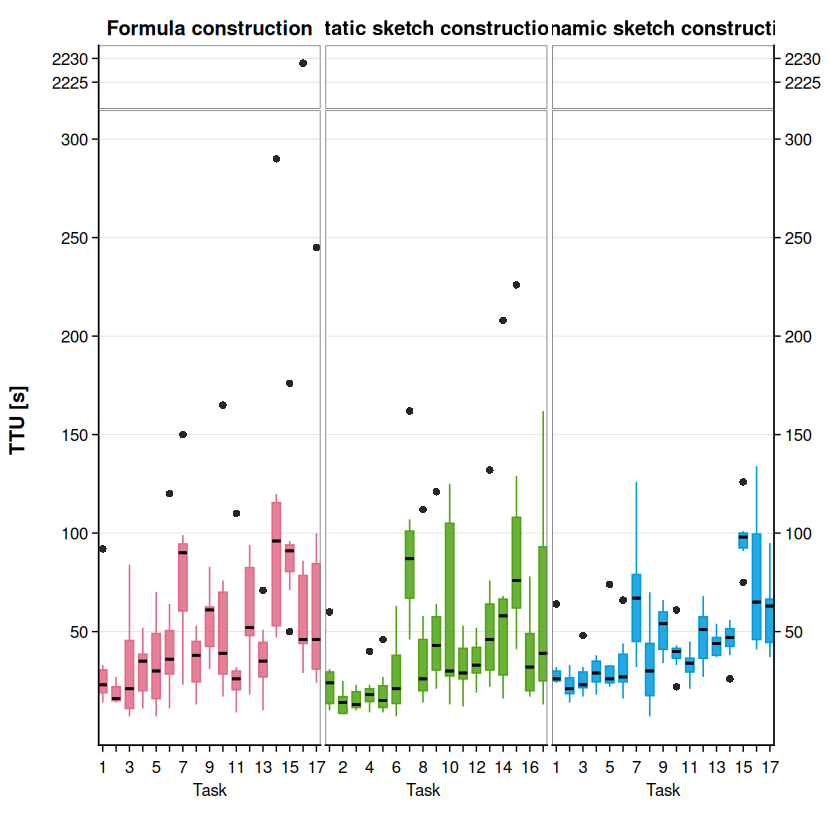

In [12]:
p_ttu <- plot_by_group_and_task(
  data = dat,
  measure = "TTU",
  y_break = c(300, 2220),
  break_scale = 1 / 10,
  width = 10,
  height = 5
)

p_ttu

note: box = interquartile range, line = median, whiskers = 1.5 IQR, dots = outliers 

PDF saved to: /home/judith/Schreibtisch/angew. Informatik - system engineering/Study_DrawingAttention/DOU_by_group_and_task.pdf



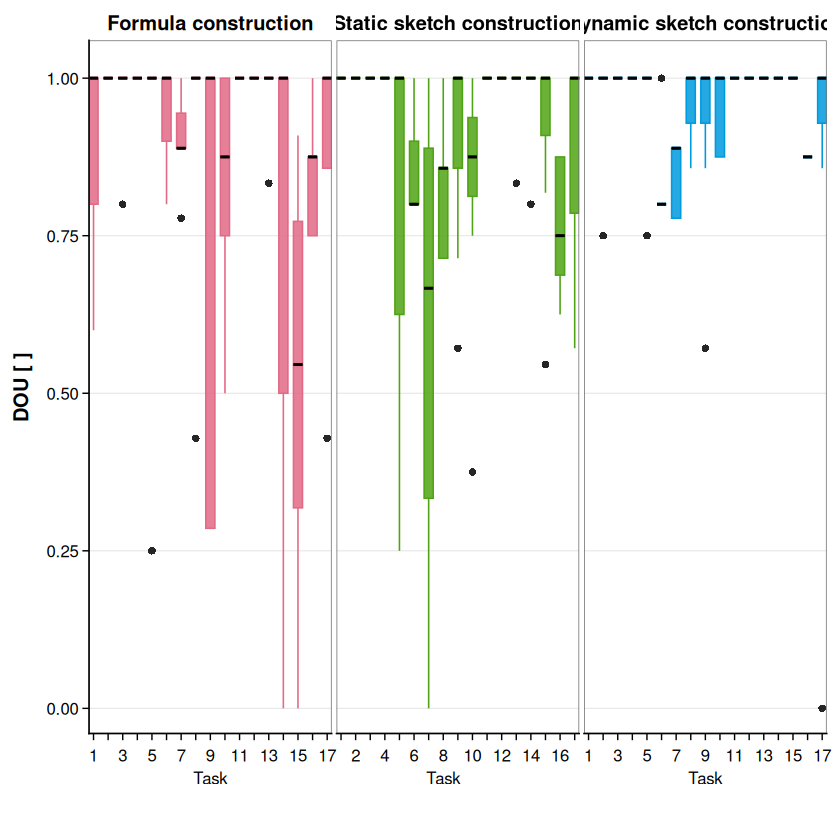

In [13]:
plot_by_group_and_task(dat, "DOU", width=10)

# 

# Inter-Rater Agreement

In [14]:
rmse <- function(x) {
  sqrt(mean(x ^ 2))
}

In [15]:
get_coding_alignment_dat <- function(dat, metric = "ttu") {
  
  metric <- tolower(metric)
  
  if (!metric %in% c("ttu", "dou", "timestamp_where_participant_realizes")) {
    stop("metric must be 'ttu' or 'dou'")
  }
  
  if (metric == "ttu") {
    x_var <- "TTU"
    y_var <- "TTU_second_coder"
  } else {
      if (metric == "timestamp_where_participant_realizes") {
        x_var <- "timestamp_where_participant_realizes"
        y_var <- "timestamp_where_participant_realizes_second_coder"
      } else {
        x_var <- "DOU"
        y_var <- "DOU_second_coder"
      }
  }
  
  split_id <- strsplit(as.character(dat$task_id), "_")
  dat$participant <- vapply(split_id, `[`, character(1), 1)
  
  plot_df <- dat[complete.cases(dat[, c(x_var, y_var)]), ]
  
  min_val <- min(plot_df[[x_var]], plot_df[[y_var]])
  max_val <- max(plot_df[[x_var]], plot_df[[y_var]])
  
  p <- ggplot(
    plot_df,
    aes_string(x = x_var, y = y_var, colour = "participant")
  ) +
    geom_point(alpha = 0.7, size = 3) +
    geom_abline(
      intercept = 0,
      slope = 1,
      linetype = "dashed",
      colour = "red"
    ) +
    coord_equal(
      xlim = c(min_val, max_val),
      ylim = c(min_val, max_val)
    ) +
    labs(
      x = paste0(toupper(metric), " (Coder 1)"),
      y = paste0(toupper(metric), " (Coder 2)"),
      colour = "Participant"
    ) +
    theme_minimal() +
    theme(legend.position = "right")
  
  # ggsave(
  #   paste0(metric, "_coding_alignment.png"),
  #   p,
  #   width = 8,
  #   height = 8,
  #   dpi = 300
  # )
  
  print(p)
  invisible(p)
}

In [16]:
coder_error_measures <- function(ratings, tol = 5) {
  if (!is.numeric(tol) || length(tol) != 1L || is.na(tol) || tol < 0) {
    stop("`tol` must be one non-negative numeric value.")
  }

  ratings <- as.data.frame(ratings)

  # Identify numeric rating columns
  numeric_columns <- vapply(ratings, is.numeric, logical(1))
  ratings <- ratings[, numeric_columns, drop = FALSE]

  if (ncol(ratings) < 2L) {
    stop("`ratings` must contain at least two numeric rating columns.")
  }

  # Use the first two numeric columns
  ratings <- ratings[, 1:2, drop = FALSE]

  # Retain complete paired observations
  ratings <- ratings[complete.cases(ratings), , drop = FALSE]

  if (nrow(ratings) == 0L) {
    stop("There are no complete paired observations.")
  }

  diff_vec <- ratings[[1]] - ratings[[2]]
  abs_diff <- abs(diff_vec)

  c(
    mean_difference             = mean(diff_vec),
    mean_absolute_error         = mean(abs_diff),
    median_absolute_error       = median(abs_diff),
    sd_difference               = sd(diff_vec),
    maximum_absolute_difference = max(abs_diff),
    rmse                        = sqrt(mean(diff_vec^2)),
    proportion_within_tolerance = mean(abs_diff <= tol)
  )
}

### TTU 

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.”


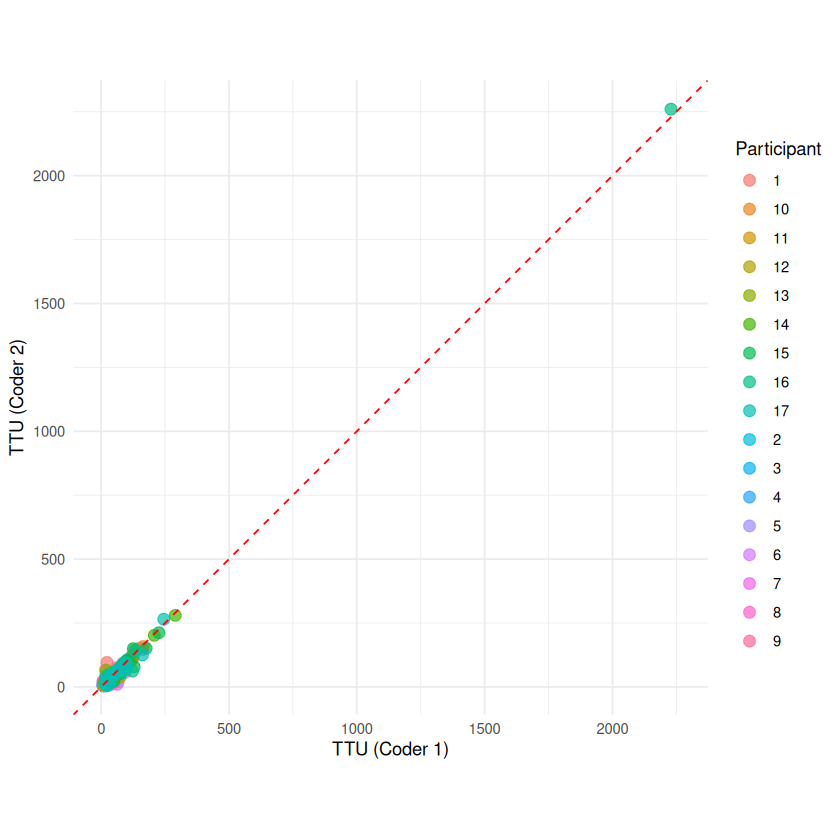

In [17]:
get_coding_alignment_dat(dat, metric = "ttu")

In [18]:
# Keep only complete paired observations
ratings <- dat[, c("TTU", "TTU_second_coder")]
ratings <- ratings[complete.cases(ratings), ]

# Two-way, absolute-agreement ICC for single coders
icc_res <- irr::icc(
  ratings,
  model = "twoway",
  type  = "agreement",
  unit  = "single"
)

print(icc_res)

 Single Score Intraclass Correlation

   Model: twoway 
   Type : agreement 

   Subjects = 357 
     Raters = 2 
   ICC(A,1) = 0.995

 F-Test, H0: r0 = 0 ; H1: r0 > 0 
 F(356,356) = 444 , p = 0 

 95%-Confidence Interval for ICC Population Values:
  0.994 < ICC < 0.996


Inter-rater agreement for Time to Understand (TTU) was excellent: 
- ICC(A,1) = 0.99
- 95% CI =  [0.985, 0.993]
- based on 102 paired observations.

In [19]:
error_summary <- coder_error_measures(ratings, tol = 5)
print(error_summary)

            mean_difference         mean_absolute_error 
                  2.6302521                   6.5238095 
      median_absolute_error               sd_difference 
                  2.0000000                  11.5815614 
maximum_absolute_difference                        rmse 
                 73.0000000                  11.8606522 
proportion_within_tolerance 
                  0.6498599 


However, absolute differences indicated a systematic discrepancy:   
Coder 1 coded TTU values 6.79 seconds higher on average than Coder 2.   
The mean absolute difference was 9.5 seconds (median = 10 seconds), and only 46% of codings were within ±5 seconds. 

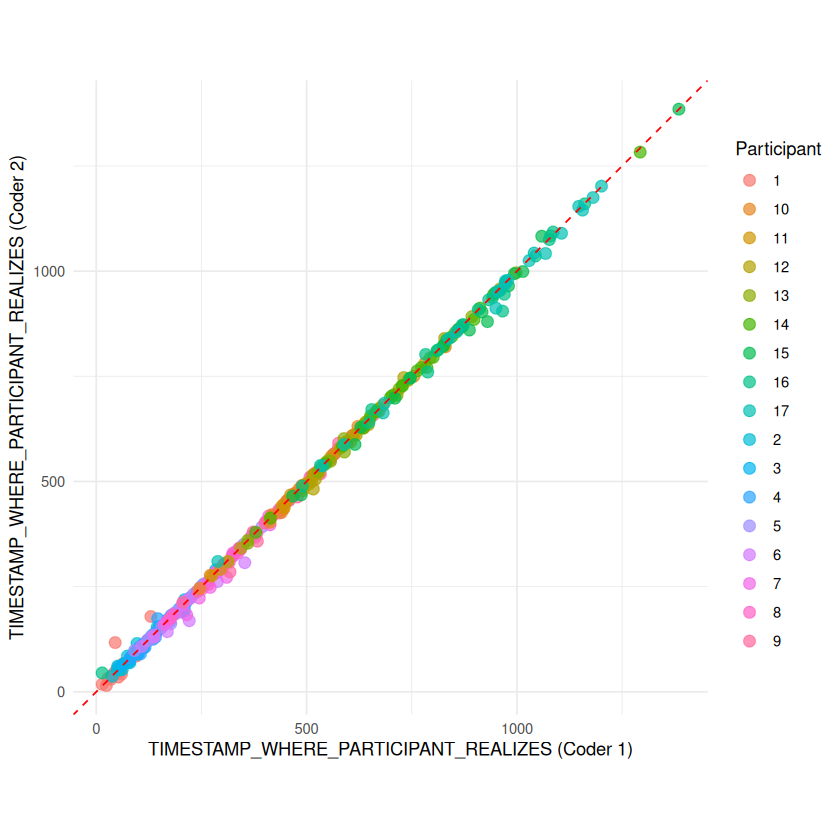

In [20]:
# timestamp_where_participant_realizes

get_coding_alignment_dat(dat, metric = "timestamp_where_participant_realizes")

In [21]:
# Keep only complete paired observations
ratings <- dat[, c("timestamp_where_participant_realizes", "timestamp_where_participant_realizes_second_coder")]
ratings <- ratings[complete.cases(ratings), ]

# Two-way, absolute-agreement ICC for single coders
icc_res <- irr::icc(
  ratings,
  model = "twoway",
  type  = "agreement",
  unit  = "single"
)

print(icc_res)

error_summary <- coder_error_measures(ratings, tol = 5)
print(error_summary)

 Single Score Intraclass Correlation

   Model: twoway 
   Type : agreement 

   Subjects = 357 
     Raters = 2 
   ICC(A,1) = 0.999

 F-Test, H0: r0 = 0 ; H1: r0 > 0 
 F(356,356) = 3040 , p = 0 

 95%-Confidence Interval for ICC Population Values:
  0.999 < ICC < 0.999
            mean_difference         mean_absolute_error 
                  2.9327731                   6.1484594 
      median_absolute_error               sd_difference 
                  2.0000000                  11.1113348 
maximum_absolute_difference                        rmse 
                 72.0000000                  11.4768065 
proportion_within_tolerance 
                  0.6834734 


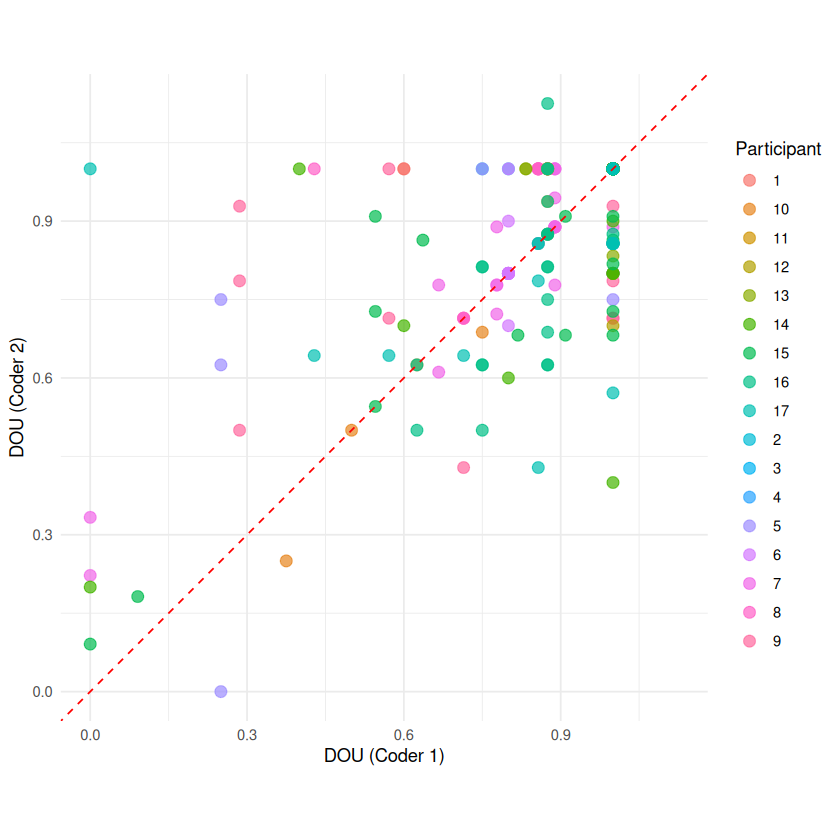

In [22]:
get_coding_alignment_dat(dat, metric = "dou")

In [23]:
# Keep only complete paired observations
ratings <- dat[, c("DOU", "DOU_second_coder")]
ratings <- ratings[complete.cases(ratings), ]

# Two-way, absolute-agreement ICC for single coders
icc_res <- irr::icc(
  ratings,
  model = "twoway",
  type  = "agreement",
  unit  = "single"
)

print(icc_res)

 Single Score Intraclass Correlation

   Model: twoway 
   Type : agreement 

   Subjects = 357 
     Raters = 2 
   ICC(A,1) = 0.689

 F-Test, H0: r0 = 0 ; H1: r0 > 0 
 F(356,356) = 5.41 , p = 7.51e-52 

 95%-Confidence Interval for ICC Population Values:
  0.63 < ICC < 0.74


Inter-rater agreement for DOU was moderate:
- ICC(A,1) = 0.501
- 95% CI [0.342, 0.633]
- based on 102 paired codings.

In [24]:
error_summary <- coder_error_measures(ratings, tol = 0.2)
print(error_summary)

            mean_difference         mean_absolute_error 
               -0.004096184                 0.063296228 
      median_absolute_error               sd_difference 
                0.000000000                 0.139669025 
maximum_absolute_difference                        rmse 
                1.000000000                 0.139533410 
proportion_within_tolerance 
                0.899159664 


### Saving the results: 

In [25]:
ratings_list <- list(
  TTU = dat[, c("TTU", "TTU_second_coder")],
  DOU = dat[, c("DOU", "DOU_second_coder")],
  TIMESTAMP_REALIZATION = dat[,c("timestamp_where_participant_realizes", "timestamp_where_participant_realizes_second_coder")]
)

# Keep complete pairs for each measure
ratings_list <- lapply(
  ratings_list,
  function(x) x[complete.cases(x), , drop = FALSE]
)

In [26]:
tolerances <- c(
  TTU = 3,
  DOU = 0.2, 
  TIMESTAMP_REALIZATION=3
)

error_results <- Map(
  function(ratings, tol) {
    coder_error_measures(ratings, tol = tol)
  },
  ratings_list,
  tolerances
)

icc_results <- lapply(
  ratings_list,
  function(ratings) {
    irr::icc(
      ratings,
      model = "twoway",
      type  = "agreement",
      unit  = "single",
      conf.level = 0.95
    )
  }
)

In [27]:
selected_measures <- c(
  "mean_difference",
  "rmse",
  "median_absolute_error"
)

error_table <- do.call(
  rbind,
  lapply(error_results, function(x) x[selected_measures])
)

error_table <- data.frame(
  Measure = names(error_results),
  error_table,
  row.names = NULL,
  check.names = FALSE
)

names(error_table) <- c(
  "Measure",
  "Mean difference",
  "RMSE",
  "Median absolute error"
)

# Extract ICC estimates and confidence limits
error_table$ICC <- vapply(
  icc_results,
  function(x) x$value,
  numeric(1)
)

error_table$CI_lower <- vapply(
  icc_results,
  function(x) x$lbound,
  numeric(1)
)

error_table$CI_upper <- vapply(
  icc_results,
  function(x) x$ubound,
  numeric(1)
)

# Combine ICC and CI into one conventionally formatted column
error_table$`ICC(2,1) [95% CI]` <- sprintf(
  "%.2f [%.2f, %.2f]",
  error_table$ICC,
  error_table$CI_lower,
  error_table$CI_upper
)

# Remove the separate intermediate ICC columns
error_table$ICC <- NULL
error_table$CI_lower <- NULL
error_table$CI_upper <- NULL

# Put ICC immediately after the measure name
error_table <- error_table[, c(
  "Measure",
  "ICC(2,1) [95% CI]",
  "Mean difference",
  "RMSE"
)]

error_table

Measure,"ICC(2,1) [95% CI]",Mean difference,RMSE
<chr>,<chr>,<dbl>,<dbl>
TTU,"1.00 [0.99, 1.00]",2.630252101,11.8606522
DOU,"0.69 [0.63, 0.74]",-0.004096184,0.1395334
TIMESTAMP_REALIZATION,"1.00 [1.00, 1.00]",2.932773109,11.4768065


In [28]:
latex_table_data <- error_table

numeric_columns <- c(
  "Mean difference",
  "RMSE"
)

latex_table_data[numeric_columns] <- lapply(
  latex_table_data[numeric_columns],
  function(x) sprintf("%.6f", x)
)

latex_table <- knitr::kable(
  latex_table_data,
  format = "latex",
  booktabs = TRUE,
  escape = TRUE,
  align = c("l", "c", "r", "r"),
  caption = "Inter-coder agreement and error measures",
  label = "tab:intercoder-agreement"
)

cat(latex_table)

\begin{table}

\caption{\label{tab:tab:intercoder-agreement}Inter-coder agreement and error measures}
\centering
\begin{tabular}[t]{lcrr}
\toprule
Measure & ICC(2,1) [95\% CI] & Mean difference & RMSE\\
\midrule
TTU & 1.00 [0.99, 1.00] & 2.630252 & 11.860652\\
DOU & 0.69 [0.63, 0.74] & -0.004096 & 0.139533\\
TIMESTAMP\_REALIZATION & 1.00 [1.00, 1.00] & 2.932773 & 11.476806\\
\bottomrule
\end{tabular}
\end{table}

# Is there evidence for differences between groups, tasks, or differing task patterns across groups?

In [29]:
report_ats <- function(
  fit,
  outcome,
  within = "task_id",
  between = "group"
) {
  
  ats <- as.data.frame(fit$ATS)
  ats$effect <- rownames(ats)
  rownames(ats) <- NULL
  
  # Identify relevant columns
  p_col <- grep(
    "p.value|p-value|pval|^p$",
    names(ats),
    ignore.case = TRUE,
    value = TRUE
  )[1]
  
  statistic_col <- grep(
    "statistic|ATS",
    names(ats),
    ignore.case = TRUE,
    value = TRUE
  )[1]
  
  df_col <- grep(
    "^df$|degrees",
    names(ats),
    ignore.case = TRUE,
    value = TRUE
  )[1]
  
  if (is.na(p_col)) {
    stop("No p-value column found. Check names(fit$ATS).")
  }
  
  make_hypothesis <- function(effect) {
    
    # Interaction effect, e.g. task_id:group
    if (grepl(":", effect, fixed = TRUE)) {
      
      parts <- strsplit(effect, ":", fixed = TRUE)[[1]]
      
      return(
        paste0(
          "H0: The effect of ", parts[1],
          " on ", outcome,
          " does not differ across levels of ", parts[2],
          " (no ", parts[1], " × ", parts[2], " interaction)."
        )
      )
    }
    
    # Between-subject effect
    if (effect == between) {
      return(
        paste0(
          "H0: There is no overall difference in ", outcome,
          " between levels of ", between, "."
        )
      )
    }
    
    # Within-subject effect
    if (effect == within) {
      return(
        paste0(
          "H0: There is no difference in ", outcome,
          " between levels of ", within, "."
        )
      )
    }
    
    # Fallback for additional effects
    paste0(
      "H0: There is no difference in ", outcome,
      " between levels of ", effect, "."
    )
  }
  
  # Ensure numeric p-values
  p_values <- as.numeric(unlist(ats[[p_col]]))
  
  data.frame(
    outcome = outcome,
    effect = ats$effect,
    
    ANOVA_Type_Statistic = if (!is.na(statistic_col)) {
      as.numeric(unlist(ats[[statistic_col]]))
    } else {
      NA_real_
    },
    
    degrees_of_freedom = if (!is.na(df_col)) {
      as.numeric(unlist(ats[[df_col]]))
    } else {
      NA_real_
    },
    
    null_hypothesis = vapply(
      ats$effect,
      make_hypothesis,
      character(1)
    ),
    
    p_value = p_values,
    
    significant = p_values < alpha,
    
    conclusion = ifelse(
      p_values < alpha,
      "Significant: reject H0",
      "Not significant: do not reject H0"
    ),
    
    row.names = NULL,
    check.names = FALSE
  )
}

In [30]:
format_table_significant_column_bold <- function(table) {
  display_table <- table %>%
    dplyr::mutate(
      significant = ifelse(
        significant,
        bold("TRUE"),
        "FALSE"
      )
    )
  html <- knitr::kable(
    display_table,
    format = "html",
    escape = FALSE,
    digits = 10
  )
  
   html_print(as.character(html))
}

In [31]:
dat <- dat %>%
  mutate(
    participant = factor(participant),
    group = factor(group),
    task_id = factor(task_id, levels = 1:17)
  )

## TTU

In [32]:
fit_ttu <- nparLD(
  TTU ~ task_id * group,
  data = dat,
  subject = "participant"
)

In [33]:
# summary(fit_ttu)

In [34]:
ats_ttu <- report_ats(
  fit = fit_ttu,
  outcome = "TTU",
  within = "task_id",
  between = "group"
)

format_table_significant_column_bold(ats_ttu)

outcome,effect,ANOVA_Type_Statistic,degrees_of_freedom,null_hypothesis,p_value,significant,conclusion
TTU,group,1.5074388,1.804142,H0: There is no overall difference in TTU between levels of group.,0.2228490,FALSE,Not significant: do not reject H0
TTU,task_id,18.7566701,8.087444,H0: There is no difference in TTU between levels of task_id.,0.0000000,TRUE,Significant: reject H0
TTU,group:task_id,0.9714015,10.110118,H0: The effect of group on TTU does not differ across levels of task_id (no group × task_id interaction).,0.4664009,FALSE,Not significant: do not reject H0


In [35]:
# get the p values with more precision: 


# ats <- as.data.frame(fit_ttu$ATS)

# stat_col <- grep(
#   "statistic|ATS",
#   names(ats),
#   ignore.case = TRUE,
#   value = TRUE
# )[1]

# df_col <- grep(
#   "^df$|degrees",
#   names(ats),
#   ignore.case = TRUE,
#   value = TRUE
# )[1]

# statistic <- as.numeric(ats[[stat_col]])
# df <- as.numeric(ats[[df_col]])

# # Stable ATS p-values
# p_stable <- stats::pchisq(
#   statistic * df,
#   df = df,
#   lower.tail = FALSE
# )

# data.frame(
#   effect = rownames(ats),
#   statistic = statistic,
#   df = df,
#   p_from_nparLD = p_values,
#   p_recalculated = sprintf("%.16e", p_stable)
# )

In [36]:
rte <- as.data.frame(fit_ttu$RTE)
rte

<0 x 0 matrix>

**-> There is a difference in TTU between levels of task_id**

Tasks differ overall, but there is no evidence that the pattern of task differences differs between participant groups.  


-> *follow-up question*: __For a given task, is there a difference in TTU/DOU across the groups?__

### TTU - video times ("TTU_mod")

In [37]:
# Initialise TTUmod as a copy of TTU
dat$TTU_mod <- dat$TTU

# Apply the subtraction only where the condition holds
idx <- dat$group == "Dynamic sketch construction"
dat$TTU_mod[idx] <- dat$TTU[idx] - dat$video_length_in_s[idx]

dat

participant,task_id,group,TTU,DOU,structural_aspects,video_length_in_s,timestamp_where_participant_realizes,TTU_second_coder,DOU_second_coder,timestamp_where_participant_realizes_second_coder,TTU_mod
<fct>,<fct>,<fct>,<dbl>,<dbl>,<list>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
p01,1,Formula construction,17,1.0,"COMP, CELL, VAL , BACK, ON",12,130,66,1,179,17
p31,1,Formula construction,23,0.6,"COMP, CELL, VAL , BACK, ON",12,45,96,1,117,23
p34,1,Formula construction,14,1.0,"COMP, CELL, VAL , BACK, ON",12,14,18,1,18,14
p33,1,Formula construction,28,1.0,"COMP, CELL, VAL , BACK, ON",12,49,33,1,54,28
p26,1,Formula construction,92,0.6,"COMP, CELL, VAL , BACK, ON",12,128,89,1,125,92
p21,1,Formula construction,33,1.0,"COMP, CELL, VAL , BACK, ON",12,64,36,1,67,33
p27,1,Formula construction,21,1.0,"COMP, CELL, VAL , BACK, ON",12,28,32,1,32,21
p11,1,Static sketch construction,10,1.0,"COMP, CELL, VAL , BACK, ON",12,36,10,1,37,10
p30,1,Static sketch construction,24,1.0,"COMP, CELL, VAL , BACK, ON",12,48,23,1,44,24


In [38]:
fit_ttu_mod <- nparLD(
  TTU_mod ~ task_id * group,
  data = dat,
  subject = "participant"
)

In [39]:
ats_ttu_mod <- report_ats(
  fit = fit_ttu_mod,
  outcome = "TTU_mod",
  within = "task_id",
  between = "group"
)

format_table_significant_column_bold(ats_ttu_mod)

outcome,effect,ANOVA_Type_Statistic,degrees_of_freedom,null_hypothesis,p_value,significant,conclusion
TTU_mod,group,9.265781,1.926980,H0: There is no overall difference in TTU_mod between levels of group.,0.000119367,TRUE,Significant: reject H0
TTU_mod,task_id,14.177923,8.576837,H0: There is no difference in TTU_mod between levels of task_id.,0.000000000,TRUE,Significant: reject H0
TTU_mod,group:task_id,1.073886,10.741638,H0: The effect of group on TTU_mod does not differ across levels of task_id (no group × task_id interaction).,0.377991791,FALSE,Not significant: do not reject H0


-> Individually, group and task_id have an effect on TTU_mod, but the group difference in TTU-mod does not depend on the task.

### DOU

In [40]:
fit_dou <- nparLD(
  DOU ~ task_id * group,
  data = dat,
  subject = "participant"
)

In [41]:
# summary(fit_dou)

In [42]:
ats_dou <- report_ats(
  fit = fit_dou,
  outcome = "DOU",
  within = "task_id",
  between = "group"
)

format_table_significant_column_bold(ats_dou)

outcome,effect,ANOVA_Type_Statistic,degrees_of_freedom,null_hypothesis,p_value,significant,conclusion
DOU,group,1.375060,1.729543,H0: There is no overall difference in DOU between levels of group.,0.25234094,FALSE,Not significant: do not reject H0
DOU,task_id,12.951066,6.576753,H0: There is no difference in DOU between levels of task_id.,0.00000000,TRUE,Significant: reject H0
DOU,group:task_id,2.452173,9.419995,H0: The effect of group on DOU does not differ across levels of task_id (no group × task_id interaction).,0.00758988,TRUE,Significant: reject H0


-> **There is a difference in DOU between levels of task_id** and **The effect of group on DOU does differ across levels of task_id.**


The group difference in DOU depends on the task.

influence of task_id always significant -> TTU/DOU differ between at least some of the 17 tasks (expected) 

-> *follow-up*: **Replace task_id with meaningful task properties**(see structural characteristics) 

# For a given task, is there a difference in TTU/DOU across the groups? 

In [43]:
kruskal_by_task <- function(
  data,
  task,
  outcome = "TTU",
  task_col = "task_id",
  group_col = "group"
) {
  
  # Prüfen, ob benötigte Spalten existieren
  required_cols <- c(task_col, group_col, outcome)
  
  if (!all(required_cols %in% names(data))) {
    stop(
      "Missing column(s): ",
      paste(setdiff(required_cols, names(data)), collapse = ", ")
    )
  }
  
  # Outcome muss numerisch sein
  if (!is.numeric(data[[outcome]])) {
    stop("Outcome column '", outcome, "' must be numeric.")
  }
  
  # Gewünschten Task sowie gültige Werte auswählen
  task_data <- data %>%
    dplyr::filter(
      .data[[task_col]] == task,
      !is.na(.data[[outcome]]),
      is.finite(.data[[outcome]]),
      !is.na(.data[[group_col]])
    )
  
  # Gruppe sicher als Faktor behandeln
  task_data[[group_col]] <- droplevels(factor(task_data[[group_col]]))
  
  n <- nrow(task_data)
  k <- nlevels(task_data[[group_col]])
  n_unique <- dplyr::n_distinct(task_data[[outcome]])
  
  if (n == 0) {
    warning(
      "Skipping task ", task, " for ", outcome,
      ": no valid observations."
    )
    return(NULL)
  }
  
  if (k < 2) {
    warning(
      "Skipping task ", task, " for ", outcome,
      ": fewer than two groups with valid observations."
    )
    return(NULL)
  }
  
  # Alle Werte identisch: Kruskal-Wallis ist nicht definiert.
  if (n_unique <= 1) {
    warning(
      "Skipping task ", task, " for ", outcome,
      ": all ", n, " valid outcome values are identical (",
      task_data[[outcome]][1], "). No group comparison is possible."
    )
    return(NULL)
  }
  
  # Dynamische Formel, z. B. TTU ~ group
  test_formula <- as.formula(
    paste(outcome, "~", group_col)
  )
  
  kw <- kruskal.test(
    formula = test_formula,
    data = task_data
  )
  
  H <- unname(kw$statistic)
  df <- unname(kw$parameter)
  p <- kw$p.value
  
  # Zusätzliche Absicherung gegen NaN/Inf
  if (!is.finite(H) || !is.finite(p)) {
    warning(
      "Skipping task ", task, " for ", outcome,
      ": Kruskal-Wallis returned a non-finite statistic or p-value."
    )
    return(NULL)
  }
  
  # Epsilon squared als Effektgröße für Kruskal-Wallis
  # Falls n == k, wäre die Effektgröße nicht definierbar.
  epsilon_squared <- if (n > k) {
    max(0, (H - k + 1) / (n - k))
  } else {
    NA_real_
  }
  
  effect_magnitude <- dplyr::case_when(
    is.na(epsilon_squared) ~ NA_character_,
    epsilon_squared < 0.01 ~ "negligible",
    epsilon_squared < 0.06 ~ "small",
    epsilon_squared < 0.14 ~ "medium",
    TRUE ~ "large"
  )
  
  data.frame(
    task_id = task,
    outcome = outcome,
    n = n,
    n_groups = k,
    n_unique_values = n_unique,
    kruskal_H = round(H, 3),
    degrees_of_freedom = df,
    p_value = p,
    
    significant = ifelse(
      p < alpha,
      "✓",
      "—"
    ),
    
    conclusion = ifelse(
      p < alpha,
      "SIGNIFICANT",
      "Not significant"
    ),
    
    effect_size = round(epsilon_squared, 7),
    effect_magnitude = effect_magnitude,
    
    row.names = NULL,
    check.names = FALSE
  )
}

In [44]:
all_tasks_kw <- function(
  data,
  outcome = "TTU",
  task_col = "task_id",
  group_col = "group"
) {
  
  tasks <- sort(unique(data[[task_col]]))
  
  results <- lapply(tasks, function(task) {
    kruskal_by_task(
      data = data,
      task = task,
      outcome = outcome,
      task_col = task_col,
      group_col = group_col
    )
  })
  
  # NULL-Ergebnisse entfernen: ausgeschlossene Tasks erscheinen nicht in der Tabelle
  results <- Filter(Negate(is.null), results)
  
  if (length(results) == 0) {
    warning("No valid Kruskal-Wallis tests could be performed for ", outcome, ".")
    return(data.frame())
  }
  
  dplyr::bind_rows(results)
}

In [45]:
cliffs_delta <- function(x, y) {
  
  x <- x[is.finite(x)]
  y <- y[is.finite(y)]
  
  comparisons <- outer(x, y, FUN = "-")
  
  (
    sum(comparisons > 0) -
    sum(comparisons < 0)
  ) / (length(x) * length(y))
}


interpret_cliffs_delta <- function(delta) {
  
  abs_delta <- abs(delta)
  
  if (abs_delta < 0.147) {
    "negligible"
  } else if (abs_delta < 0.330) {
    "small"
  } else if (abs_delta < 0.474) {
    "medium"
  } else {
    "large"
  }
}

In [46]:
posthoc_by_task <- function(
  data,
  task,
  outcome = "TTU",
  task_col = "task_id",
  group_col = "group"
) {
  
  # First: omnibus Kruskal-Wallis test
  omnibus <- kruskal_by_task(
    data = data,
    task = task,
    outcome = outcome,
    task_col = task_col,
    group_col = group_col
  )
  
  # Task may have been skipped due to no variation etc.
  if (is.null(omnibus)) {
    return(NULL)
  }
  
  # Post-hoc only after significant omnibus test
  if (omnibus$p_value >= alpha) {
    message(
      "Skipping post-hoc for task ", task,
      " (", outcome, "): Kruskal-Wallis is not significant; p = ",
      format.pval(omnibus$p_value, digits = 3, eps = 0.001)
    )
    return(NULL)
  }
  
  # Select valid observations for this task
  task_data <- data %>%
    dplyr::filter(
      .data[[task_col]] == task,
      !is.na(.data[[outcome]]),
      is.finite(.data[[outcome]]),
      !is.na(.data[[group_col]])
    )
  
  task_data[[group_col]] <- droplevels(
    factor(task_data[[group_col]])
  )
  
  groups <- levels(task_data[[group_col]])
  
  if (length(groups) < 2) {
    warning("Fewer than two valid groups for task ", task, ".")
    return(NULL)
  }
  
  # All group pairs, e.g. A-B, A-C, B-C
  group_pairs <- combn(groups, 2, simplify = FALSE)
  
  # Run pairwise Wilcoxon rank-sum tests
  results <- lapply(group_pairs, function(pair) {
    
    group_1 <- pair[1]
    group_2 <- pair[2]
    
    x <- task_data[[outcome]][
      task_data[[group_col]] == group_1
    ]
    
    y <- task_data[[outcome]][
      task_data[[group_col]] == group_2
    ]
    
    # exact = FALSE is important when there are ties
    test <- wilcox.test(
      x,
      y,
      paired = FALSE,
      exact = FALSE
    )
    
    delta <- cliffs_delta(x, y)
    
    data.frame(
      task_id = task,
      outcome = outcome,
      group1 = group_1,
      group2 = group_2,
      n_group1 = length(x),
      n_group2 = length(y),
      W = unname(test$statistic),
      p_value = test$p.value,
      cliffs_delta = delta,
      effect_magnitude = interpret_cliffs_delta(delta),
      direction = ifelse(
        delta > 0,
        paste(group_1, "higher than", group_2),
        ifelse(
          delta < 0,
          paste(group_2, "higher than", group_1),
          "No directional difference"
        )
      ),
      row.names = NULL,
      check.names = FALSE
    )
  })
  
  results <- dplyr::bind_rows(results) %>%
    dplyr::mutate(
      p_holm = p.adjust(p_value, method = "holm"),
      
      significant = ifelse(
        p_holm < alpha,
        "✓",
        "—"
      ),
      
      conclusion = ifelse(
        p_holm < alpha,
        "SIGNIFICANT after Holm correction",
        "Not significant after Holm correction"
      ),
      
      cliffs_delta = round(cliffs_delta, 7)
    ) %>%
    dplyr::select(
      task_id,
      outcome,
      group1,
      group2,
      # n_group1,
      # n_group2,
      W,
      p_value,
      p_holm,
      significant,
      conclusion,
      cliffs_delta,
      effect_magnitude,
      direction
    )
  
  results
}

In [47]:
compact_letters_by_task <- function(
  data,
  posthoc_results,
  task,
  outcome_name,
  task_col = "task_id",
  group_col = "group"
) {
  
  # Passende Post-hoc-Vergleiche auswählen
  comparisons <- posthoc_results %>%
    dplyr::filter(
      .data$task_id == task,
      .data$outcome == outcome_name
    )
  
  if (nrow(comparisons) == 0) {
    warning(
      "No post-hoc comparisons found for task ", task,
      " and outcome ", outcome_name, "."
    )
    return(NULL)
  }
  
  # Holm-korrigierte Signifikanz der Paarvergleiche
  comparison_names <- paste(
    comparisons$group1,
    comparisons$group2,
    sep = "-"
  )
  
  significant_comparisons <- comparisons$p_holm < alpha
  names(significant_comparisons) <- comparison_names
  
  # Compact Letter Display erzeugen
  letters <- multcompView::multcompLetters(
    significant_comparisons
  )$Letters
  
  cld <- data.frame(
    task_id = task,
    outcome = outcome_name,
    group = names(letters),
    compact_letter = unname(letters),
    row.names = NULL
  )
  
  # Originaldaten dieses Tasks auswählen und Gruppenkennwerte berechnen
  task_data <- data %>%
    dplyr::filter(
      .data[[task_col]] == task,
      !is.na(.data[[outcome_name]]),
      is.finite(.data[[outcome_name]]),
      !is.na(.data[[group_col]])
    )
  
  summary_data <- task_data %>%
    dplyr::group_by(group = .data[[group_col]]) %>%
    dplyr::summarise(
      n = dplyr::n(),
      median = median(.data[[outcome_name]]),
      q1 = quantile(.data[[outcome_name]], 0.25),
      q3 = quantile(.data[[outcome_name]], 0.75),
      mean = mean(.data[[outcome_name]]),
      .groups = "drop"
    )
  
  # Mediane und Buchstaben verbinden
  summary_data %>%
    dplyr::left_join(cld, by = "group") %>%
    dplyr::select(
      task_id,
      outcome,
      group,
      n,
      median,
      q1,
      q3,
      mean,
      compact_letter
    ) %>%
    dplyr::arrange(median)
}

In [48]:
#summarizing post hoc test and CLD:
posthoc_and_cld <- function(data,
                            task,
                            outcome_name) {
  if (!outcome_name %in% names(data)) {
    stop(
      sprintf(
        "Outcome column '%s' not found in `data`. Available columns are: %s",
        outcome_name,
        paste(names(data), collapse = ", ")
      ),
      call. = FALSE
    )
  }

  posthoc_res <- posthoc_by_task(
    data    = data,
    task    = task,
    outcome = outcome_name   
  )

  cld_res <- compact_letters_by_task(
    data            = data,
    posthoc_results = posthoc_res,
    task            = task,
    outcome_name    = outcome_name
  )

  list(
    posthoc = posthoc_res,
    cld     = cld_res
  )
}

In [49]:
export_outcome_table <- function(
  ...,
  tex_file = "outcome_results.tex"
) {

  # --------------------------------------------------------------------------
  # Use global alpha
  # --------------------------------------------------------------------------

  if (!exists("alpha", inherits = TRUE)) {
    stop("Global variable 'alpha' was not found.")
  }

  alpha_value <- get("alpha", inherits = TRUE)

  if (
    length(alpha_value) != 1 ||
    !is.numeric(alpha_value) ||
    !is.finite(alpha_value) ||
    alpha_value <= 0 ||
    alpha_value >= 1
  ) {
    stop("Global variable 'alpha' must be one number between 0 and 1.")
  }

  # --------------------------------------------------------------------------
  # Collect data frames
  # --------------------------------------------------------------------------

  data_list <- list(...)

  # Also allow a single named list of data frames
  if (
    length(data_list) == 1 &&
    is.list(data_list[[1]]) &&
    !is.data.frame(data_list[[1]])
  ) {
    data_list <- data_list[[1]]
  }

  if (length(data_list) == 0) {
    stop("At least one data frame must be supplied.")
  }

  if (!all(vapply(data_list, is.data.frame, logical(1)))) {
    stop("All supplied objects must be data frames.")
  }

  required_columns <- c(
    "task_id",
    "outcome",
    "p_value",
    "effect_size"
  )

  for (i in seq_along(data_list)) {

    missing_columns <- setdiff(
      required_columns,
      names(data_list[[i]])
    )

    if (length(missing_columns) > 0) {
      stop(
        "Data frame ", i, " is missing column(s): ",
        paste(missing_columns, collapse = ", ")
      )
    }

    if (anyDuplicated(as.character(data_list[[i]]$task_id))) {
      stop(
        "Data frame ", i,
        " contains duplicated task_id values."
      )
    }
  }

  # --------------------------------------------------------------------------
  # Determine outcome names
  #
  # Named arguments such as TTU = kw_ttu take precedence over the outcome
  # column.
  # --------------------------------------------------------------------------

  input_names <- names(data_list)

  if (is.null(input_names)) {
    input_names <- rep("", length(data_list))
  }

  outcome_names <- character(length(data_list))

  for (i in seq_along(data_list)) {

    if (
      length(input_names) >= i &&
      !is.na(input_names[i]) &&
      nzchar(input_names[i])
    ) {

      outcome_names[i] <- input_names[i]

    } else {

      current_outcomes <- unique(
        as.character(
          data_list[[i]]$outcome[
            !is.na(data_list[[i]]$outcome)
          ]
        )
      )

      if (length(current_outcomes) != 1) {
        stop(
          "Data frame ", i,
          " must contain exactly one non-missing outcome value, ",
          "or it must be supplied as a named argument."
        )
      }

      outcome_names[i] <- current_outcomes
    }
  }

  # --------------------------------------------------------------------------
  # Preserve task ordering across the supplied data frames
  # --------------------------------------------------------------------------

  task_ids <- unique(
    unlist(
      lapply(
        data_list,
        function(x) as.character(x$task_id)
      ),
      use.names = FALSE
    )
  )

  # --------------------------------------------------------------------------
  # LaTeX helper functions
  # --------------------------------------------------------------------------

  latex_escape <- function(x) {

    x <- as.character(x)

    vapply(
      x,
      function(value) {

        if (is.na(value)) {
          return("")
        }

        characters <- strsplit(
          value,
          "",
          fixed = TRUE
        )[[1]]

        replacements <- c(
          "&" = "\\&",
          "%" = "\\%",
          "$" = "\\$",
          "#" = "\\#",
          "_" = "\\_",
          "{" = "\\{",
          "}" = "\\}",
          "~" = "\\textasciitilde{}",
          "^" = "\\textasciicircum{}"
        )

        paste0(
          vapply(
            characters,
            function(character) {
              if (character %in% names(replacements)) {
                replacements[[character]]
              } else {
                character
              }
            },
            character(1)
          ),
          collapse = ""
        )
      },
      character(1)
    )
  }

  # Exactly six decimal places, enclosed in \num{...}.
  # Significant values are additionally enclosed in \underline{...}.
  format_num <- function(x, underline = FALSE) {

    numeric_x <- suppressWarnings(
      as.numeric(as.character(x))
    )

    if (length(underline) == 1) {
      underline <- rep(underline, length(numeric_x))
    }

    underline[is.na(underline)] <- FALSE

    vapply(
      seq_along(numeric_x),
      function(i) {

        value <- numeric_x[i]

        if (is.na(value)) {
          return("")
        }

        if (!is.finite(value)) {
          return(latex_escape(as.character(value)))
        }

        # Prevent negative zero after rounding.
        if (abs(value) < 0.5e-6) {
          value <- 0
        }

        latex_value <- paste0(
          "\\num{",
          sprintf("%.6f", value),
          "}"
        )

        if (isTRUE(underline[i])) {
          latex_value <- paste0(
            "\\underline{",
            latex_value,
            "}"
          )
        }

        latex_value
      },
      character(1)
    )
  }

  # Task IDs remain plain text/numbers.
  format_task_id <- function(x) {
    latex_escape(as.character(x))
  }

  # --------------------------------------------------------------------------
  # Align all data frames by task_id
  # --------------------------------------------------------------------------

  table_columns <- list(
    Task = format_task_id(task_ids)
  )

  for (i in seq_along(data_list)) {

    current_data <- data_list[[i]]

    row_indices <- match(
      task_ids,
      as.character(current_data$task_id)
    )

    current_p <- suppressWarnings(
      as.numeric(
        as.character(
          current_data$p_value[row_indices]
        )
      )
    )

    current_effect <- suppressWarnings(
      as.numeric(
        as.character(
          current_data$effect_size[row_indices]
        )
      )
    )

    # Significance is determined independently for each outcome.
    current_significant <- (
      !is.na(current_p) &
        current_p < alpha_value
    )

    table_columns[[paste0("p_", i)]] <- format_num(
      current_p,
      underline = current_significant
    )

    table_columns[[paste0("effect_", i)]] <- format_num(
      current_effect,
      underline = current_significant
    )
  }

  table_data <- as.data.frame(
    table_columns,
    stringsAsFactors = FALSE,
    check.names = FALSE
  )

  # --------------------------------------------------------------------------
  # Construct two-row header
  # --------------------------------------------------------------------------

  n_outcomes <- length(data_list)

  outcome_header <- paste0(
    "& ",
    paste(
      paste0(
        "\\multicolumn{2}{c}{",
        latex_escape(outcome_names),
        "}"
      ),
      collapse = " & "
    ),
    " \\\\"
  )

  cmidrules <- paste(
    vapply(
      seq_len(n_outcomes),
      function(i) {

        first_column <- 2 + (i - 1) * 2
        last_column <- first_column + 1

        paste0(
          "\\cmidrule(lr){",
          first_column,
          "-",
          last_column,
          "}"
        )
      },
      character(1)
    ),
    collapse = " "
  )

  second_header <- paste0(
    "Task & ",
    paste(
      rep(
        c("$p$-value", "Effect size"),
        times = n_outcomes
      ),
      collapse = " & "
    ),
    " \\\\"
  )

  # --------------------------------------------------------------------------
  # Construct table rows
  # --------------------------------------------------------------------------

  table_rows <- vapply(
    seq_len(nrow(table_data)),
    function(i) {
      paste0(
        paste(
          as.character(table_data[i, ]),
          collapse = " & "
        ),
        " \\\\"
      )
    },
    character(1)
  )

  column_alignment <- paste0(
    "l",
    paste(
      rep("rr", n_outcomes),
      collapse = ""
    )
  )

  # --------------------------------------------------------------------------
  # Construct only the tabular environment
  # --------------------------------------------------------------------------

  latex_output <- c(
    paste0(
      "\\begin{tabular}{",
      column_alignment,
      "}"
    ),
    "\\toprule",
    outcome_header,
    cmidrules,
    second_header,
    "\\midrule",
    table_rows,
    "\\bottomrule",
    "\\end{tabular}"
  )

  writeLines(
    latex_output,
    con = tex_file,
    useBytes = TRUE
  )

  message(
    "LaTeX tabular saved to: ",
    normalizePath(tex_file, mustWork = FALSE)
  )

  invisible(latex_output)
}

### H0: There is no difference in TTU between participant groups for task ...

In [50]:
kw_ttu <- all_tasks_kw(
  data = dat,
  outcome = "TTU"
)

kw_ttu

task_id,outcome,n,n_groups,n_unique_values,kruskal_H,degrees_of_freedom,p_value,significant,conclusion,effect_size,effect_magnitude
<fct>,<chr>,<int>,<int>,<int>,<dbl>,<int>,<dbl>,<chr>,<chr>,<dbl>,<chr>
1,TTU,21,3,15,1.447,2,0.48499205,—,Not significant,0.0000000,negligible
2,TTU,21,3,14,5.361,2,0.06852499,—,Not significant,0.1867285,large
3,TTU,21,3,14,4.042,2,0.13253232,—,Not significant,0.1134365,medium
4,TTU,21,3,14,3.836,2,0.14687788,—,Not significant,0.1020171,medium
5,TTU,21,3,20,3.394,2,0.18326269,—,Not significant,0.0774261,medium
6,TTU,21,3,19,1.629,2,0.44281574,—,Not significant,0.0000000,negligible
7,TTU,21,3,20,1.760,2,0.41479215,—,Not significant,0.0000000,negligible
8,TTU,21,3,20,0.072,2,0.96444583,—,Not significant,0.0000000,negligible
9,TTU,21,3,19,0.570,2,0.75189622,—,Not significant,0.0000000,negligible


-> **The test did not find sufficient statistical evidence that the participant groups differ for this task and metric.**

 Looking at TTU_mod instead, we find:

In [51]:
kw_ttu_mod <- all_tasks_kw(
  data = dat,
  outcome = "TTU_mod"
)

kw_ttu_mod

task_id,outcome,n,n_groups,n_unique_values,kruskal_H,degrees_of_freedom,p_value,significant,conclusion,effect_size,effect_magnitude
<fct>,<chr>,<int>,<int>,<int>,<dbl>,<int>,<dbl>,<chr>,<chr>,<dbl>,<chr>
1,TTU_mod,21,3,16,2.850,2,0.240548941,—,Not significant,0.0472035,small
2,TTU_mod,21,3,13,4.781,2,0.091573503,—,Not significant,0.1545126,large
3,TTU_mod,21,3,14,2.698,2,0.259459556,—,Not significant,0.0387949,small
4,TTU_mod,21,3,16,3.673,2,0.159336861,—,Not significant,0.0929705,medium
5,TTU_mod,21,3,19,1.808,2,0.404939398,—,Not significant,0.0000000,negligible
6,TTU_mod,21,3,18,3.368,2,0.185598156,—,Not significant,0.0760190,medium
7,TTU_mod,21,3,20,4.552,2,0.102687948,—,Not significant,0.1417845,large
8,TTU_mod,21,3,19,2.474,2,0.290187413,—,Not significant,0.0263587,small
9,TTU_mod,21,3,20,8.889,2,0.011743628,✓,SIGNIFICANT,0.3827160,large


In [52]:
result__TTU_mod <- posthoc_and_cld(
  data         = dat,
  task         = 9,
  outcome_name = "TTU_mod"
)

result__TTU_mod$posthoc
result__TTU_mod$cld 

task_id,outcome,group1,group2,W,p_value,p_holm,significant,conclusion,cliffs_delta,effect_magnitude,direction
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>
9,TTU_mod,Dynamic sketch construction,Formula construction,2,0.004937905,0.01481372,✓,SIGNIFICANT after Holm correction,-0.9183673,large,Formula construction higher than Dynamic sketch construction
9,TTU_mod,Dynamic sketch construction,Static sketch construction,8,0.040691939,0.08138388,—,Not significant after Holm correction,-0.6734694,large,Static sketch construction higher than Dynamic sketch construction
9,TTU_mod,Formula construction,Static sketch construction,29,0.608886305,0.60888631,—,Not significant after Holm correction,0.1836735,small,Formula construction higher than Static sketch construction


task_id,outcome,group,n,median,q1,q3,mean,compact_letter
<dbl>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
9,TTU_mod,Dynamic sketch construction,7,24,11.0,30.0,20.85714,a
9,TTU_mod,Static sketch construction,7,43,30.5,57.5,51.57143,ab
9,TTU_mod,Formula construction,7,61,42.5,62.5,55.00000,b


In [53]:
result__TTU_mod <- posthoc_and_cld(
  data         = dat,
  task         = 11,
  outcome_name = "TTU_mod"
)

result__TTU_mod$posthoc
result__TTU_mod$cld 

task_id,outcome,group1,group2,W,p_value,p_holm,significant,conclusion,cliffs_delta,effect_magnitude,direction
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>
11,TTU_mod,Dynamic sketch construction,Formula construction,8.0,0.04047062,0.08094123,—,Not significant after Holm correction,-0.6734694,large,Formula construction higher than Dynamic sketch construction
11,TTU_mod,Dynamic sketch construction,Static sketch construction,4.5,0.01252091,0.03756274,✓,SIGNIFICANT after Holm correction,-0.8163265,large,Static sketch construction higher than Dynamic sketch construction
11,TTU_mod,Formula construction,Static sketch construction,18.0,0.44127370,0.44127370,—,Not significant after Holm correction,-0.2653061,small,Static sketch construction higher than Formula construction


task_id,outcome,group,n,median,q1,q3,mean,compact_letter
<dbl>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
11,TTU_mod,Dynamic sketch construction,7,14,9.5,16.5,13.14286,a
11,TTU_mod,Formula construction,7,26,20.5,30.0,35.14286,ab
11,TTU_mod,Static sketch construction,7,29,26.0,41.5,32.71429,b


In [54]:
result__TTU_mod <- posthoc_and_cld(
  data         = dat,
  task         = 12,
  outcome_name = "TTU_mod"
)

result__TTU_mod$posthoc
result__TTU_mod$cld 

task_id,outcome,group1,group2,W,p_value,p_holm,significant,conclusion,cliffs_delta,effect_magnitude,direction
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>
12,TTU_mod,Dynamic sketch construction,Formula construction,6.5,0.02518656,0.07555969,—,Not significant after Holm correction,-0.7346939,large,Formula construction higher than Dynamic sketch construction
12,TTU_mod,Dynamic sketch construction,Static sketch construction,20.0,0.60769758,0.60769758,—,Not significant after Holm correction,-0.1836735,small,Static sketch construction higher than Dynamic sketch construction
12,TTU_mod,Formula construction,Static sketch construction,39.5,0.06333570,0.12667141,—,Not significant after Holm correction,0.6122449,large,Formula construction higher than Static sketch construction


task_id,outcome,group,n,median,q1,q3,mean,compact_letter
<dbl>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
12,TTU_mod,Dynamic sketch construction,7,33,18.5,39.5,29.71429,a
12,TTU_mod,Static sketch construction,7,33,29.0,42.0,35.14286,a
12,TTU_mod,Formula construction,7,52,48.0,82.5,60.71429,a


In [55]:
result__TTU_mod <- posthoc_and_cld(
  data         = dat,
  task         = 13,
  outcome_name = "TTU_mod"
)

result__TTU_mod$posthoc
result__TTU_mod$cld 

task_id,outcome,group1,group2,W,p_value,p_holm,significant,conclusion,cliffs_delta,effect_magnitude,direction
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>
13,TTU_mod,Dynamic sketch construction,Formula construction,5.5,0.017707662,0.03541532,✓,SIGNIFICANT after Holm correction,-0.7755102,large,Formula construction higher than Dynamic sketch construction
13,TTU_mod,Dynamic sketch construction,Static sketch construction,1.5,0.003920737,0.01176221,✓,SIGNIFICANT after Holm correction,-0.9387755,large,Static sketch construction higher than Dynamic sketch construction
13,TTU_mod,Formula construction,Static sketch construction,16.0,0.306685066,0.30668507,—,Not significant after Holm correction,-0.3469388,medium,Static sketch construction higher than Formula construction


task_id,outcome,group,n,median,q1,q3,mean,compact_letter
<dbl>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
13,TTU_mod,Dynamic sketch construction,7,15,9.0,18.0,14.57143,a
13,TTU_mod,Formula construction,7,35,27.0,44.5,37.00000,b
13,TTU_mod,Static sketch construction,7,46,30.5,64.0,55.57143,b


In [56]:
result__TTU_mod <- posthoc_and_cld(
  data         = dat,
  task         = 14,
  outcome_name = "TTU_mod"
)

result__TTU_mod$posthoc
result__TTU_mod$cld 

task_id,outcome,group1,group2,W,p_value,p_holm,significant,conclusion,cliffs_delta,effect_magnitude,direction
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>
14,TTU_mod,Dynamic sketch construction,Formula construction,0.0,0.00214071,0.006422129,✓,SIGNIFICANT after Holm correction,-1.0000000,large,Formula construction higher than Dynamic sketch construction
14,TTU_mod,Dynamic sketch construction,Static sketch construction,10.5,0.08385019,0.167700390,—,Not significant after Holm correction,-0.5714286,large,Static sketch construction higher than Dynamic sketch construction
14,TTU_mod,Formula construction,Static sketch construction,34.0,0.25015301,0.250153008,—,Not significant after Holm correction,0.3877551,medium,Formula construction higher than Static sketch construction


task_id,outcome,group,n,median,q1,q3,mean,compact_letter
<dbl>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
14,TTU_mod,Dynamic sketch construction,7,25,20.5,29.5,23.28571,a
14,TTU_mod,Static sketch construction,7,58,28.0,66.5,67.28571,ab
14,TTU_mod,Formula construction,7,96,53.0,115.5,110.00000,b


In [57]:
result__TTU_mod <- posthoc_and_cld(
  data         = dat,
  task         = 15,
  outcome_name = "TTU_mod"
)

result__TTU_mod$posthoc
result__TTU_mod$cld 

task_id,outcome,group1,group2,W,p_value,p_holm,significant,conclusion,cliffs_delta,effect_magnitude,direction
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>
15,TTU_mod,Dynamic sketch construction,Formula construction,2.0,0.004937905,0.01481372,✓,SIGNIFICANT after Holm correction,-0.9183673,large,Formula construction higher than Dynamic sketch construction
15,TTU_mod,Dynamic sketch construction,Static sketch construction,5.5,0.017959832,0.03591966,✓,SIGNIFICANT after Holm correction,-0.7755102,large,Static sketch construction higher than Dynamic sketch construction
15,TTU_mod,Formula construction,Static sketch construction,29.5,0.564870837,0.56487084,—,Not significant after Holm correction,0.2040816,small,Formula construction higher than Static sketch construction


task_id,outcome,group,n,median,q1,q3,mean,compact_letter
<dbl>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
15,TTU_mod,Dynamic sketch construction,7,45,39.5,47,44.71429,a
15,TTU_mod,Static sketch construction,7,76,62.0,108,97.57143,b
15,TTU_mod,Formula construction,7,91,80.5,94,95.14286,b


## H0: There is no difference in DOU between participant groups for task ...

In [58]:
kw_dou <- all_tasks_kw(
  data = dat,
  outcome = "DOU"
)

kw_dou

Warning message in kruskal_by_task(data = data, task = task, outcome = outcome, :
“Skipping task 4 for DOU: all 21 valid outcome values are identical (1). No group comparison is possible.”
Warning message in kruskal_by_task(data = data, task = task, outcome = outcome, :
“Skipping task 11 for DOU: all 21 valid outcome values are identical (1). No group comparison is possible.”
Warning message in kruskal_by_task(data = data, task = task, outcome = outcome, :
“Skipping task 12 for DOU: all 21 valid outcome values are identical (1). No group comparison is possible.”


task_id,outcome,n,n_groups,n_unique_values,kruskal_H,degrees_of_freedom,p_value,significant,conclusion,effect_size,effect_magnitude
<fct>,<chr>,<int>,<int>,<int>,<dbl>,<int>,<dbl>,<chr>,<chr>,<dbl>,<chr>
1,DOU,21,3,2,4.211,2,0.121813614,—,Not significant,0.1228070,medium
2,DOU,21,3,2,2.000,2,0.367879441,—,Not significant,0.0000000,negligible
3,DOU,21,3,2,2.000,2,0.367879441,—,Not significant,0.0000000,negligible
5,DOU,21,3,3,0.778,2,0.677809578,—,Not significant,0.0000000,negligible
6,DOU,21,3,2,5.000,2,0.082084999,—,Not significant,0.1666667,large
7,DOU,21,3,5,4.056,2,0.131631162,—,Not significant,0.1141946,medium
8,DOU,21,3,4,6.929,2,0.031286266,✓,SIGNIFICANT,0.2738418,large
9,DOU,21,3,5,1.344,2,0.510707800,—,Not significant,0.0000000,negligible
10,DOU,21,3,6,1.901,2,0.386509511,—,Not significant,0.0000000,negligible


-> For **task 8 and 15** there are **possible differences in DOU** across the groups. 

-> Performing a post hoc test: 



In [59]:
export_outcome_table(
  TTU = kw_ttu,
  DOU = kw_dou,
  tex_file = "ttu_dou_results.tex"
)

LaTeX tabular saved to: /home/judith/Schreibtisch/angew. Informatik - system engineering/Study_DrawingAttention/ttu_dou_results.tex



Task 8: 

In [60]:
result__DOU <- posthoc_and_cld(
  data         = dat,
  task         = 8,
  outcome_name = "DOU"
)

result__DOU$posthoc
result__DOU$cld 

task_id,outcome,group1,group2,W,p_value,p_holm,significant,conclusion,cliffs_delta,effect_magnitude,direction
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>
8,DOU,Dynamic sketch construction,Formula construction,22.0,0.72157973,0.72157973,—,Not significant after Holm correction,-0.1020408,negligible,Formula construction higher than Dynamic sketch construction
8,DOU,Dynamic sketch construction,Static sketch construction,41.5,0.02382753,0.07148259,—,Not significant after Holm correction,0.6938776,large,Dynamic sketch construction higher than Static sketch construction
8,DOU,Formula construction,Static sketch construction,39.0,0.05364264,0.10728527,—,Not significant after Holm correction,0.5918367,large,Formula construction higher than Static sketch construction


task_id,outcome,group,n,median,q1,q3,mean,compact_letter
<dbl>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
8,DOU,Static sketch construction,7,0.8571429,0.7142857,0.8571429,0.8163265,a
8,DOU,Dynamic sketch construction,7,1.0000000,0.9285714,1.0000000,0.9591837,a
8,DOU,Formula construction,7,1.0000000,1.0000000,1.0000000,0.9183673,a


**-> No significant difference between groups in Task 8 after correction.**

Task 15: 

In [61]:
result__DOU <- posthoc_and_cld(
  data         = dat,
  task         = 15,
  outcome_name = "DOU"
)

result__DOU$posthoc
result__DOU$cld 

task_id,outcome,group1,group2,W,p_value,p_holm,significant,conclusion,cliffs_delta,effect_magnitude,direction
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>
15,DOU,Dynamic sketch construction,Formula construction,49.0,0.001027148,0.003081445,✓,SIGNIFICANT after Holm correction,1.0000000,large,Dynamic sketch construction higher than Formula construction
15,DOU,Dynamic sketch construction,Static sketch construction,31.5,0.172954918,0.172954918,—,Not significant after Holm correction,0.2857143,small,Dynamic sketch construction higher than Static sketch construction
15,DOU,Formula construction,Static sketch construction,6.0,0.017987746,0.035975491,✓,SIGNIFICANT after Holm correction,-0.7551020,large,Static sketch construction higher than Formula construction


task_id,outcome,group,n,median,q1,q3,mean,compact_letter
<dbl>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
15,DOU,Formula construction,7,0.5454545,0.3181818,0.7727273,0.5194805,b
15,DOU,Dynamic sketch construction,7,1.0000000,1.0000000,1.0000000,1.0000000,a
15,DOU,Static sketch construction,7,1.0000000,0.9090909,1.0000000,0.9090909,a


**-> Group "Formula construction" performs worse than the others for task 15, by - in median - understanding about half of the task only.**

The "Formula construction" group underperforms compared to the others on task 15, with a median understanding of only about half the task.

In [62]:
export_posthoc_subtables <- function(
  posthoc,
  cld,
  tex_file = "posthoc_subtables.tex"
) {

  # --------------------------------------------------------------------------
  # Checks
  # --------------------------------------------------------------------------

  if (!is.data.frame(posthoc)) {
    stop("'posthoc' must be a data frame.")
  }

  if (!is.data.frame(cld)) {
    stop("'cld' must be a data frame.")
  }

  required_posthoc <- c(
    "task_id",
    "outcome",
    "group1",
    "group2",
    "p_value",
    "p_holm",
    "cliffs_delta"
  )

  required_cld <- c(
    "task_id",
    "outcome",
    "group",
    "mean",
    "median",
    "compact_letter"
  )

  missing_posthoc <- setdiff(
    required_posthoc,
    names(posthoc)
  )

  missing_cld <- setdiff(
    required_cld,
    names(cld)
  )

  if (length(missing_posthoc) > 0) {
    stop(
      "'posthoc' is missing column(s): ",
      paste(missing_posthoc, collapse = ", ")
    )
  }

  if (length(missing_cld) > 0) {
    stop(
      "'cld' is missing column(s): ",
      paste(missing_cld, collapse = ", ")
    )
  }

  # --------------------------------------------------------------------------
  # Use global alpha
  # --------------------------------------------------------------------------

  if (!exists("alpha", inherits = TRUE)) {
    stop("Global variable 'alpha' was not found.")
  }

  alpha_value <- get("alpha", inherits = TRUE)

  if (
    length(alpha_value) != 1 ||
    !is.numeric(alpha_value) ||
    !is.finite(alpha_value) ||
    alpha_value <= 0 ||
    alpha_value >= 1
  ) {
    stop("Global variable 'alpha' must be one number between 0 and 1.")
  }

  # --------------------------------------------------------------------------
  # Identify task and outcome
  # --------------------------------------------------------------------------

  all_tasks <- unique(c(
    as.character(cld$task_id),
    as.character(posthoc$task_id)
  ))

  all_tasks <- all_tasks[
    !is.na(all_tasks) & nzchar(all_tasks)
  ]

  all_outcomes <- unique(c(
    as.character(cld$outcome),
    as.character(posthoc$outcome)
  ))

  all_outcomes <- all_outcomes[
    !is.na(all_outcomes) & nzchar(all_outcomes)
  ]

  if (length(all_tasks) == 0) {
    stop("No valid task_id found.")
  }

  if (length(all_outcomes) == 0) {
    stop("No valid outcome found.")
  }

  # A common unit label requires one outcome per exported table.
  if (length(all_outcomes) != 1) {
    stop(
      "The supplied data must contain exactly one outcome because ",
      "the unit is displayed in the Mean and Median column labels."
    )
  }

  outcome_value <- toupper(all_outcomes[1])

  unit_label <- if (outcome_value == "TTU") {
    "[s]"
  } else if (outcome_value == "DOU") {
    "$[\\,]$"
  } else {
    ""
  }

  # --------------------------------------------------------------------------
  # LaTeX helpers
  # --------------------------------------------------------------------------

  latex_escape <- function(x) {

    x <- as.character(x)

    vapply(
      x,
      function(value) {

        if (is.na(value)) {
          return("")
        }

        characters <- strsplit(
          value,
          "",
          fixed = TRUE
        )[[1]]

        replacements <- c(
          "&" = "\\&",
          "%" = "\\%",
          "$" = "\\$",
          "#" = "\\#",
          "_" = "\\_",
          "{" = "\\{",
          "}" = "\\}",
          "~" = "\\textasciitilde{}",
          "^" = "\\textasciicircum{}"
        )

        paste0(
          vapply(
            characters,
            function(character) {

              if (character %in% names(replacements)) {
                replacements[[character]]
              } else {
                character
              }
            },
            character(1)
          ),
          collapse = ""
        )
      },
      character(1)
    )
  }

  format_outcome <- function(x) {

    x <- as.character(x)

    vapply(
      x,
      function(value) {

        if (is.na(value)) {
          return("")
        }

        if (toupper(value) == "DOU") {
          return("\\dou\\")
        }

        if (toupper(value) == "TTU") {
          return("\\ttu\\")
        }

        latex_escape(value)
      },
      character(1)
    )
  }

  format_group <- function(x) {

    x <- as.character(x)

    vapply(
      x,
      function(value) {

        if (is.na(value)) {
          return("")
        }

        paste0(
          "\\enquote{",
          latex_escape(value),
          "}"
        )
      },
      character(1)
    )
  }

  # Exactly six decimal places
  format_num <- function(x, underline = FALSE) {

    numeric_x <- suppressWarnings(
      as.numeric(as.character(x))
    )

    if (length(underline) == 1L) {
      underline <- rep(underline, length(numeric_x))
    }

    if (length(underline) != length(numeric_x)) {
      stop(
        "'underline' must have length one or the same length as 'x'."
      )
    }

    underline[is.na(underline)] <- FALSE

    vapply(
      seq_along(numeric_x),
      function(i) {

        value <- numeric_x[i]

        if (is.na(value)) {
          return("")
        }

        if (!is.finite(value)) {
          return(latex_escape(as.character(value)))
        }

        # Avoid negative zero after rounding.
        if (abs(value) < 0.5e-6) {
          value <- 0
        }

        result <- paste0(
          "\\num{",
          sprintf("%.6f", value),
          "}"
        )

        if (isTRUE(underline[i])) {
          result <- paste0(
            "\\underline{",
            result,
            "}"
          )
        }

        result
      },
      character(1)
    )
  }

  # --------------------------------------------------------------------------
  # First subtable: pairwise comparisons
  # --------------------------------------------------------------------------

  p_holm_numeric <- suppressWarnings(
    as.numeric(as.character(posthoc$p_holm))
  )

  significant <- (
    !is.na(p_holm_numeric) &
      p_holm_numeric < alpha_value
  )

  comparison <- paste0(
    format_group(posthoc$group1),
    " vs. ",
    format_group(posthoc$group2)
  )

  posthoc_table <- data.frame(
    comparison = comparison,
    p_value = format_num(
      posthoc$p_value,
      underline = significant
    ),
    p_holm = format_num(
      posthoc$p_holm,
      underline = significant
    ),
    cliffs_delta = format_num(
      posthoc$cliffs_delta,
      underline = significant
    ),
    stringsAsFactors = FALSE,
    check.names = FALSE
  )

  posthoc_rows <- vapply(
    seq_len(nrow(posthoc_table)),
    function(i) {
      paste0(
        paste(
          as.character(posthoc_table[i, ]),
          collapse = " & "
        ),
        " \\\\"
      )
    },
    character(1)
  )

  # --------------------------------------------------------------------------
  # Second subtable: group summaries
  # --------------------------------------------------------------------------

  cld_table <- data.frame(
    group = format_group(cld$group),
    mean = format_num(cld$mean),
    median = format_num(cld$median),
    compact_letter = latex_escape(cld$compact_letter),
    stringsAsFactors = FALSE,
    check.names = FALSE
  )

  cld_rows <- vapply(
    seq_len(nrow(cld_table)),
    function(i) {
      paste0(
        paste(
          as.character(cld_table[i, ]),
          collapse = " & "
        ),
        " \\\\"
      )
    },
    character(1)
  )

  # --------------------------------------------------------------------------
  # Comments containing task and outcome information
  # --------------------------------------------------------------------------

  task_comment <- paste0(
    "% Task: ",
    paste(
      latex_escape(all_tasks),
      collapse = ", "
    )
  )

  outcome_comment <- paste0(
    "% Outcome: ",
    format_outcome(all_outcomes)
  )

  alpha_comment <- paste0(
    "% Significance threshold: p_Holm < ",
    format(alpha_value, scientific = FALSE, trim = TRUE)
  )

  # --------------------------------------------------------------------------
  # Column labels with outcome-specific units
  # --------------------------------------------------------------------------

  mean_header <- if (nzchar(unit_label)) {
    paste("Mean", unit_label)
  } else {
    "Mean"
  }

  median_header <- if (nzchar(unit_label)) {
    paste("Median", unit_label)
  } else {
    "Median"
  }

  # --------------------------------------------------------------------------
  # Construct only the two subtable environments
  #
  # Order:
  #   1. Pairwise comparisons
  #   2. Group summaries
  # --------------------------------------------------------------------------

  latex_output <- c(
    task_comment,
    outcome_comment,
    alpha_comment,
    "",
    "\\begin{subtable}[t]{\\textwidth}",
    "\\centering",
    "\\caption{Pairwise group comparisons}",
    "\\begin{tabular}{lrrr}",
    "\\toprule",
    paste0(
      "Comparison & $p$-value & ",
      "$p_{\\mathrm{Holm}}$ & Cliff's $\\delta$ \\\\"
    ),
    "\\midrule",
    posthoc_rows,
    "\\bottomrule",
    "\\end{tabular}",
    "\\end{subtable}",
    "",
    "\\vspace{0.8em}",
    "",
    "\\begin{subtable}[t]{\\textwidth}",
    "\\centering",
    "\\caption{Group summaries}",
    "\\begin{tabular}{lrrc}",
    "\\toprule",
    paste0(
      "Group & ",
      mean_header,
      " & ",
      median_header,
      " & Compact letter \\\\"
    ),
    "\\midrule",
    cld_rows,
    "\\bottomrule",
    "\\end{tabular}",
    "\\end{subtable}"
  )

  # --------------------------------------------------------------------------
  # Export
  # --------------------------------------------------------------------------

  writeLines(
    latex_output,
    con = tex_file,
    useBytes = TRUE
  )

  message(
    "LaTeX subtables saved to: ",
    normalizePath(tex_file, mustWork = FALSE)
  )

  invisible(latex_output)
}

In [63]:
export_posthoc_subtables(
  posthoc = result__DOU$posthoc,
  cld = result__DOU$cld,
  tex_file = "dou_posthoc_subtables.tex"
)

LaTeX subtables saved to: /home/judith/Schreibtisch/angew. Informatik - system engineering/Study_DrawingAttention/dou_posthoc_subtables.tex



# For a specific property of tasks, is there a difference in TTU/DOU across the groups? 

In [64]:
cat ("H₀: Across tasks with property ..., there is no overall difference in TTU/DOU between participant groups.")

H₀: Across tasks with property ..., there is no overall difference in TTU/DOU between participant groups.

In [65]:
filter_by_property <- function(
  data,
  property_col,
  property_value
) {
  
  if (!property_col %in% names(data)) {
    stop("Column not found: ", property_col)
  }
  
  data[
    vapply(
      data[[property_col]],
      function(x) property_value %in% x,
      logical(1)
    ),
  ]
}

In [66]:
interpret_group_and_interaction <- function(
  report,
  task_col = "task_id",
  group_col = "group"
) {
  
  group_result <- report %>%
    dplyr::filter(effect == group_col)
  
  interaction_result <- report %>%
    dplyr::filter(
      grepl(task_col, effect, fixed = TRUE) &
      grepl(group_col, effect, fixed = TRUE)
    )
  
  if (nrow(group_result) == 0) {
    warning("No group effect found in report.")
    return(NULL)
  }
  
  if (nrow(interaction_result) == 0) {
    warning("No task × group interaction found in report.")
    return(NULL)
  }
  
  # Wichtig: p-Werte sicher in einzelne numerische Werte umwandeln
  group_p <- as.numeric(unlist(group_result$p_value))[1]
  interaction_p <- as.numeric(unlist(interaction_result$p_value))[1]
  
  group_significant <- !is.na(group_p) && group_p < alpha
  interaction_significant <- !is.na(interaction_p) &&
    interaction_p < alpha
  
  cat("\n\n\n\nInterpretation:\n")
  
  if (!group_significant && !interaction_significant) {
    
    interpretation <- "Not significant."
    
    followup <- ""
    
  } else if (group_significant && !interaction_significant) {
    
    interpretation <- "Significant effect of participant group."
    
    followup <- paste0(
      "global pairwise group post-hoc tests with Holm correction"
    )
    
  } else if (!group_significant && interaction_significant) {
    
    interpretation <- "Task-dependent group differences."
    
    followup <- paste0(
      "See task-specific group comparisons. ",
      "Do not create one global compact letter display."
    )
    
  } else {
    
    interpretation <- paste0(
      # "Significant group effects, but group differences are task-dependent."
        "**-> task-abhängig, aber keine signifikanten Gruppenunterschiede**"
    )
    
    followup <- paste0(
      "See task-specific group comparisons. No global compact letter display possible"
    )
  }
  
  cat(interpretation, "\n")
  cat("Recommended follow-up: ", followup, "\n", sep = "")
  
  invisible(
    list(
      group_p = group_p,
      interaction_p = interaction_p,
      group_significant = group_significant,
      interaction_significant = interaction_significant,
      interpretation = interpretation,
      followup = followup# TODO follow-up kursiv
    )
  )
}



analyse_property <- function(
  data,
  property_col = "structural_aspects",
  property_value,
  outcome = "TTU",
  task_col = "task_id",
  group_col = "group",
  participant_col = "participant"
) {
  
  cat("\n")
  cat(strrep("=", 75), "\n")
  cat("PROPERTY ANALYSIS\tfor ", property_value, " with outcome = ", outcome, "\n")
  cat(strrep("=", 75), "\n")

  # 1. Tasks mit dieser Property auswählen
  property_data <- filter_by_property(
    data = data,
    property_col = property_col,
    property_value = property_value
  )
  
  # 2. Enthaltene Tasks ermitteln
  included_tasks <- property_data %>%
    dplyr::distinct(.data[[task_col]]) %>%
    dplyr::arrange(.data[[task_col]]) %>%
    dplyr::pull(.data[[task_col]])
  
  cat(
    "Included tasks (", length(included_tasks), "): ",
    paste(included_tasks, collapse = ", "),
    "\n",
    sep = ""
  )
  
  if (nrow(property_data) == 0) {
    warning(
      "No data found for property '", property_value,
      "' in column '", property_col, "'."
    )
    return(NULL)
  }
  
  # Mindestens zwei Tasks nötig für task_id * group
  if (length(included_tasks) < 2) {
    warning(
      "Skipping Brunner-Langer analysis for property '", property_value,
      "': only one task is included. "
    )
    return(list(
      property = property_value,
      outcome = outcome,
      included_tasks = included_tasks,
      data = property_data,
      fit = NULL,
      report = NULL
    ))
  }
  
  # 3. Faktoren vorbereiten
  property_data <- property_data %>%
    dplyr::mutate(
      "{participant_col}" := factor(.data[[participant_col]]),
      "{group_col}" := factor(.data[[group_col]]),
      "{task_col}" := factor(
        .data[[task_col]],
        levels = sort(unique(.data[[task_col]]))
      )
    )
  
  # 4. Dynamische Formel erzeugen, z. B. TTU ~ task_id * group
  test_formula <- as.formula(
    paste(outcome, "~", task_col, "*", group_col)
  )
  
  # 5. Brunner-Langer-Test
  fit <- tryCatch(
    nparLD::nparLD(
      formula = test_formula,
      data = property_data,
      subject = participant_col
    ),
    error = function(e) {
      warning(
        "nparLD failed for property '", property_value,
        "' and outcome '", outcome, "': ", e$message
      )
      NULL
    }
  )
  
  if (is.null(fit)) {
    return(list(
      property = property_value,
      outcome = outcome,
      included_tasks = included_tasks,
      data = property_data,
      fit = NULL,
      report = NULL
    ))
  }
  
  # 6. ATS-Ergebnis über deine vorhandene Funktion aufbereiten
  report <- report_ats(
    fit = fit,
    outcome = outcome,
    within = task_col,
    between = group_col
  )
  
  cat("\nATS results:\n")
  
  print(
  report %>%
    dplyr::filter(
      effect == group_col |
        (
          grepl(task_col, effect, fixed = TRUE) &
          grepl(group_col, effect, fixed = TRUE)
        )
    ) %>%
    dplyr::select(
      effect,
      ANOVA_Type_Statistic,
      degrees_of_freedom,
      p_value,
      significant
    )
  )

  interpretation <- interpret_group_and_interaction(
      report = report,
      task_col = task_col,
      group_col = group_col
    )
      
  # Alles für spätere Verwendung zurückgeben
  list(
    property_column = property_col,
    property = property_value,
    outcome = outcome,
    included_tasks = included_tasks,
    data = property_data,
    fit = fit,
    report = report
  )
}

In [67]:
analyse_property_both_outcomes <- function(
  data,
  property_value,
  property_col = "structural_aspects",
  outcomes = c("TTU", "DOU")
) {
  
  results <- list()
  
  for (outcome in outcomes) {
    
    cat("\n", strrep("=", 80), "\n", sep = "")
    cat(
      "Property: ", property_value,
      " | Outcome: ", outcome,
      "\n",
      sep = ""
    )
    cat(strrep("=", 80), "\n", sep = "")
    
    results[[outcome]] <- analyse_property(
      data = data,
      property_col = property_col,
      property_value = property_value,
      outcome = outcome
    )
  }
  
  invisible(results)
}
# INFO: results in: 
# return_value$TTU
# return_value$DOU

In [68]:
pairwise_property_nparld <- function(
  property_result,
  task_col = "task_id",
  group_col = "group",
  participant_col = "participant"
) {
  
  property_data <- property_result$data
  outcome <- property_result$outcome
  
  groups <- levels(
    droplevels(
      factor(property_data[[group_col]])
    )
  )
  
  if (length(groups) < 2) {
    stop("At least two groups are required.")
  }
  
  group_pairs <- combn(groups, 2, simplify = FALSE)
  
  results <- lapply(group_pairs, function(pair) {
    
    group_1 <- pair[1]
    group_2 <- pair[2]
    
    pair_data <- property_data %>%
      dplyr::filter(
        .data[[group_col]] %in% pair
      ) %>%
      dplyr::mutate(
        "{participant_col}" := factor(.data[[participant_col]]),
        "{group_col}" := factor(.data[[group_col]]),
        "{task_col}" := factor(.data[[task_col]])
      )
    
    test_formula <- as.formula(
      paste(outcome, "~", task_col, "*", group_col)
    )
    
    # Pairwise Brunner-Langer mixed-design analysis
    fit_pair <- nparLD::nparLD(
      formula = test_formula,
      data = pair_data,
      subject = participant_col
    )
    
    # Pairwise ATS report
    pair_report <- report_ats(
      fit = fit_pair,
      outcome = outcome,
      within = task_col,
      between = group_col
    )
    
    # Extract only the between-group effect
    group_result <- pair_report %>%
      dplyr::filter(effect == group_col)
    
    if (nrow(group_result) != 1) {
      stop(
        "Could not extract exactly one group effect for comparison: ",
        group_1, " vs. ", group_2
      )
    }
    
    # One result row per group pair.
    # RTE is stored as the original vector from fit_pair$effects$RTE.
    test_row <- data.frame(
      outcome = outcome,
      group1 = group_1,
      group2 = group_2,
      ANOVA_Type_Statistic = as.numeric(
        unlist(group_result$ANOVA_Type_Statistic)
      )[1],
      degrees_of_freedom = as.numeric(
        unlist(group_result$degrees_of_freedom)
      )[1],
      p_value = as.numeric(
        unlist(group_result$p_value)
      )[1],
      row.names = NULL,
      check.names = FALSE
    )
    
    test_row$RTE <- list(fit_pair$effects$RTE)
    
    test_row
  })
  
  tests <- dplyr::bind_rows(results) %>%
    dplyr::mutate(
      p_holm = p.adjust(p_value, method = "holm"),
      significant = p_holm < alpha,
      conclusion = ifelse(
        significant,
        "Significant after Holm correction",
        "Not significant after Holm correction"
      )
    )
  
  list(
    tests = tests
  )
}

In [69]:
# wenn immer noch significant -> CLD and meidan-trend

cld_from_pairwise_nparld <- function(
  posthoc_results,
  data,
  outcome,
  group_col = "group"
) {
  
  # CLD aus den Holm-korrigierten paarweisen nparLD-Tests
  pair_significant <- posthoc_results$p_holm < alpha
  
  names(pair_significant) <- paste(
    posthoc_results$group1,
    posthoc_results$group2,
    sep = "-"
  )
  
  letters <- multcompView::multcompLetters(
    pair_significant
  )$Letters
  
  cld <- data.frame(
    group = names(letters),
    compact_letter = unname(letters),
    row.names = NULL
  )
  
  # Median je Gruppe über alle in `data` enthaltenen Property-Tasks
  medians <- data %>%
    dplyr::filter(
      !is.na(.data[[outcome]]),
      is.finite(.data[[outcome]])
    ) %>%
    dplyr::group_by(group = .data[[group_col]]) %>%
    dplyr::summarise(
      n = dplyr::n(),
      mean = mean(.data[[outcome]]),
      median = median(.data[[outcome]]),
      q1 = quantile(.data[[outcome]], 0.25),
      q3 = quantile(.data[[outcome]], 0.75),
      .groups = "drop"
    )
  
  # Median und CLD verbinden; Gruppen nach Median sortieren
  medians %>%
    dplyr::left_join(cld, by = "group") %>%
    dplyr::arrange(median)
}

In [70]:
property_results_to_dataframe <- function(
  property_results,
  existing_data = NULL
) {

  new_results <- list()

  for (outcome_name in names(property_results)) {

    current_result <- property_results[[outcome_name]]

    if (
      is.null(current_result) ||
      is.null(current_result$report)
    ) {
      next
    }

    current_report <- current_result$report

    new_results[[outcome_name]] <- data.frame(
      property_value = rep(
        as.character(current_result$property),
        nrow(current_report)
      ),
      outcome = rep(
        as.character(current_result$outcome),
        nrow(current_report)
      ),
      effect = as.character(current_report$effect),
      p_value = as.numeric(
        unlist(current_report$p_value)
      ),
      stringsAsFactors = FALSE,
      row.names = NULL
    )
  }

  new_results <- dplyr::bind_rows(new_results)

  if (nrow(new_results) == 0) {
    warning("No valid results were found.")

    if (is.null(existing_data)) {
      return(
        data.frame(
          property_value = character(),
          outcome = character(),
          effect = character(),
          p_value = numeric()
        )
      )
    }

    return(existing_data)
  }

  # If no previous data frame exists, return the new results.
  if (is.null(existing_data)) {
    return(new_results)
  }

  required_columns <- c(
    "property_value",
    "outcome",
    "effect",
    "p_value"
  )

  missing_columns <- setdiff(
    required_columns,
    names(existing_data)
  )

  if (length(missing_columns) > 0) {
    stop(
      "'existing_data' is missing column(s): ",
      paste(missing_columns, collapse = ", ")
    )
  }

  # Append rather than replace.
  dplyr::bind_rows(
    existing_data,
    new_results
  )
}

In [71]:
# alle vergebenen task properties: 
all_structural_aspects <- sort(
  unique(
    unlist(dat$structural_aspects)
  )
)

all_structural_aspects

[1] "BACK"    "BATCH"   "CELL"    "COMP"    "COND"    "CROSS"   "FORWARD"
 [8] "FUNC"    "LIST"    "LIT"     "LOOK"    "OFF"     "ON"      "RANGE"  
[15] "VAL"

### COMP

In [72]:
x = analyse_property_both_outcomes(data = dat, property_value="COMP")

property_results_df <- property_results_to_dataframe(x)


Property: COMP | Outcome: TTU

PROPERTY ANALYSIS	for  COMP  with outcome =  TTU 
Included tasks (11): 1, 2, 3, 4, 7, 8, 9, 11, 12, 13, 15

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group            1.0510744           1.824183 0.3445260       FALSE
2 group:task_id            0.9257079           7.907112 0.4928112       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 

Property: COMP | Outcome: DOU

PROPERTY ANALYSIS	for  COMP  with outcome =  DOU 
Included tasks (11): 1, 2, 3, 4, 7, 8, 9, 11, 12, 13, 15

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom      p_value
1         group             2.307771           1.723237 0.1075507375
2 group:task_id             3.878630           7.179544 0.0002704798
  significant
1       FALSE
2        TRUE




Interpretation:
Task-dependent group differences. 
Recommended follow-up: See task-specific group comparisons. Do not create one global compact l

### COND

In [73]:
x = analyse_property_both_outcomes(data = dat, property_value="COND")

property_results_df <- property_results_to_dataframe(
  property_results = x,
  existing_data = property_results_df
)


Property: COND | Outcome: TTU

PROPERTY ANALYSIS	for  COND  with outcome =  TTU 
Included tasks (4): 10, 15, 16, 17

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group            0.5184467           1.706931 0.5667205       FALSE
2 group:task_id            1.6235575           3.911025 0.1665770       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 

Property: COND | Outcome: DOU

PROPERTY ANALYSIS	for  COND  with outcome =  DOU 
Included tasks (4): 10, 15, 16, 17

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom    p_value significant
1         group             3.266873           1.708035 0.04582343        TRUE
2 group:task_id             2.723752           4.536427 0.02213397        TRUE




Interpretation:
**-> task-abhängig, aber keine signifikanten Gruppenunterschiede** 
Recommended follow-up: See task-specific group comparisons. No global compact letter display possible


In [74]:
# posthoc_comp_dou <- pairwise_property_nparld(
#   property_result = x$DOU
# )
# posthoc_comp_dou

In [75]:
# cld_comp_dou <- cld_from_pairwise_nparld(
#   posthoc_results = posthoc_comp_dou,
#   data = x$DOU$data,
#   outcome = "DOU"
# )
# cld_comp_dou

### LOOK

In [76]:
x = analyse_property_both_outcomes(data = dat, property_value="LOOK")

property_results_df <- property_results_to_dataframe(
  property_results = x,
  existing_data = property_results_df
)


Property: LOOK | Outcome: TTU

PROPERTY ANALYSIS	for  LOOK  with outcome =  TTU 
Included tasks (3): 14, 15, 17

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group            0.7309042           1.538883 0.4479721       FALSE
2 group:task_id            2.1118378           2.804757 0.1008229       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 

Property: LOOK | Outcome: DOU

PROPERTY ANALYSIS	for  LOOK  with outcome =  DOU 
Included tasks (3): 14, 15, 17

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom     p_value significant
1         group             5.186325           1.785170 0.007556946        TRUE
2 group:task_id             3.668919           3.070401 0.011069706        TRUE




Interpretation:
**-> task-abhängig, aber keine signifikanten Gruppenunterschiede** 
Recommended follow-up: See task-specific group comparisons. No global compact letter display possible


## Operand Types
### CELL

In [77]:
x = analyse_property_both_outcomes(data = dat, property_value="CELL")

property_results_df <- property_results_to_dataframe(
  property_results = x,
  existing_data = property_results_df
)


Property: CELL | Outcome: TTU

PROPERTY ANALYSIS	for  CELL  with outcome =  TTU 
Included tasks (11): 1, 3, 4, 8, 9, 10, 11, 12, 13, 14, 15

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group            0.9916576           1.930962 0.3686399       FALSE
2 group:task_id            0.8669931           8.586697 0.5498900       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 

Property: CELL | Outcome: DOU

PROPERTY ANALYSIS	for  CELL  with outcome =  DOU 
Included tasks (11): 1, 3, 4, 8, 9, 10, 11, 12, 13, 14, 15

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom     p_value significant
1         group             5.824479           1.741050 0.004554492        TRUE
2 group:task_id             2.882925           7.054085 0.005065089        TRUE




Interpretation:
**-> task-abhängig, aber keine signifikanten Gruppenunterschiede** 
Recommended follow-up: See task-specific group comparisons. No glo

### RANGE

In [78]:
x = analyse_property_both_outcomes(data = dat, property_value="CELL")

property_results_df <- property_results_to_dataframe(
  property_results = x,
  existing_data = property_results_df
)


Property: CELL | Outcome: TTU

PROPERTY ANALYSIS	for  CELL  with outcome =  TTU 
Included tasks (11): 1, 3, 4, 8, 9, 10, 11, 12, 13, 14, 15

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group            0.9916576           1.930962 0.3686399       FALSE
2 group:task_id            0.8669931           8.586697 0.5498900       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 

Property: CELL | Outcome: DOU

PROPERTY ANALYSIS	for  CELL  with outcome =  DOU 
Included tasks (11): 1, 3, 4, 8, 9, 10, 11, 12, 13, 14, 15

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom     p_value significant
1         group             5.824479           1.741050 0.004554492        TRUE
2 group:task_id             2.882925           7.054085 0.005065089        TRUE




Interpretation:
**-> task-abhängig, aber keine signifikanten Gruppenunterschiede** 
Recommended follow-up: See task-specific group comparisons. No glo

### LIT

In [79]:
x = analyse_property_both_outcomes(data = dat, property_value="LIT")

property_results_df <- property_results_to_dataframe(
  property_results = x,
  existing_data = property_results_df
)


Property: LIT | Outcome: TTU

PROPERTY ANALYSIS	for  LIT  with outcome =  TTU 
Included tasks (5): 3, 8, 10, 15, 16

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group             1.025016           1.828877 0.3534328       FALSE
2 group:task_id             1.334033           4.835115 0.2477385       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 

Property: LIT | Outcome: DOU

PROPERTY ANALYSIS	for  LIT  with outcome =  DOU 
Included tasks (5): 3, 8, 10, 15, 16

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom     p_value significant
1         group             6.827789           1.853183 0.001475000        TRUE
2 group:task_id             4.376270           4.545313 0.000878805        TRUE




Interpretation:
**-> task-abhängig, aber keine signifikanten Gruppenunterschiede** 
Recommended follow-up: See task-specific group comparisons. No global compact letter display possible


### FUNC

In [80]:
x = analyse_property_both_outcomes(data = dat, property_value="FUNC")

property_results_df <- property_results_to_dataframe(
  property_results = x,
  existing_data = property_results_df
)


Property: FUNC | Outcome: TTU

PROPERTY ANALYSIS	for  FUNC  with outcome =  TTU 
Included tasks (4): 5, 6, 7, 15

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group            0.5642298           1.577210 0.5285035       FALSE
2 group:task_id            1.4393225           4.288117 0.2146810       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 

Property: FUNC | Outcome: DOU

PROPERTY ANALYSIS	for  FUNC  with outcome =  DOU 
Included tasks (4): 5, 6, 7, 15

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom      p_value
1         group            0.2902663           1.837120 0.7292653812
2 group:task_id            7.0620262           2.794395 0.0001505919
  significant
1       FALSE
2        TRUE




Interpretation:
Task-dependent group differences. 
Recommended follow-up: See task-specific group comparisons. Do not create one global compact letter display.


## RESULT TYPE
### VAL 

In [81]:
x = analyse_property_both_outcomes(data = dat, property_value="VAL")

property_results_df <- property_results_to_dataframe(
  property_results = x,
  existing_data = property_results_df
)


Property: VAL | Outcome: TTU

PROPERTY ANALYSIS	for  VAL  with outcome =  TTU 
Included tasks (14): 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group             1.045736           1.766365 0.3444414       FALSE
2 group:task_id             1.013764           9.112606 0.4262340       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 

Property: VAL | Outcome: DOU

PROPERTY ANALYSIS	for  VAL  with outcome =  DOU 
Included tasks (14): 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom      p_value
1         group             1.456973           1.677938 0.2339554432
2 group:task_id             3.445509           7.823263 0.0006336115
  significant
1       FALSE
2        TRUE




Interpretation:
Task-dependent group differences. 
Recommended follow-up: See task-specific group comparisons. Do not create on

### BATCH

In [82]:
x = analyse_property_both_outcomes(data = dat, property_value="BATCH")

property_results_df <- property_results_to_dataframe(
  property_results = x,
  existing_data = property_results_df
)


Property: BATCH | Outcome: TTU

PROPERTY ANALYSIS	for  BATCH  with outcome =  TTU 
Included tasks (1): 9


Warning message in analyse_property(data = data, property_col = property_col, property_value = property_value, :
“Skipping Brunner-Langer analysis for property 'BATCH': only one task is included. ”



Property: BATCH | Outcome: DOU

PROPERTY ANALYSIS	for  BATCH  with outcome =  DOU 
Included tasks (1): 9


Warning message in analyse_property(data = data, property_col = property_col, property_value = property_value, :
“Skipping Brunner-Langer analysis for property 'BATCH': only one task is included. ”
Warning message in property_results_to_dataframe(property_results = x, existing_data = property_results_df):
“No valid results were found.”


### LIST

In [83]:
x = analyse_property_both_outcomes(data = dat, property_value="LIST")

property_results_df <- property_results_to_dataframe(
  property_results = x,
  existing_data = property_results_df
)


Property: LIST | Outcome: TTU

PROPERTY ANALYSIS	for  LIST  with outcome =  TTU 
Included tasks (2): 16, 17

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group             1.718048           1.750510 0.1835588       FALSE
2 group:task_id             1.122838           1.893677 0.3231467       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 

Property: LIST | Outcome: DOU

PROPERTY ANALYSIS	for  LIST  with outcome =  DOU 
Included tasks (2): 16, 17

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group            0.8410042           1.910954 0.4267054       FALSE
2 group:task_id            0.2270273           1.958696 0.7923385       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 


## Ref. direction
### BACK

In [84]:
x = analyse_property_both_outcomes(data = dat, property_value="BACK")

property_results_df <- property_results_to_dataframe(
  property_results = x,
  existing_data = property_results_df
)


Property: BACK | Outcome: TTU

PROPERTY ANALYSIS	for  BACK  with outcome =  TTU 
Included tasks (13): 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 16

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group            1.2712227           1.709665 0.2776616       FALSE
2 group:task_id            0.9463302           9.375108 0.4852411       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 

Property: BACK | Outcome: DOU

PROPERTY ANALYSIS	for  BACK  with outcome =  DOU 
Included tasks (13): 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 16

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group             1.586046           1.792191 0.2070266       FALSE
2 group:task_id             1.588499           8.294430 0.1192102       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 


### FORW

In [85]:
x = analyse_property_both_outcomes(data = dat, property_value="FORWARD")

property_results_df <- property_results_to_dataframe(
  property_results = x,
  existing_data = property_results_df
)


Property: FORWARD | Outcome: TTU

PROPERTY ANALYSIS	for  FORWARD  with outcome =  TTU 
Included tasks (6): 4, 12, 13, 14, 15, 17

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group             1.269133           1.828967 0.2795788       FALSE
2 group:task_id             1.598630           5.263016 0.1528881       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 

Property: FORWARD | Outcome: DOU

PROPERTY ANALYSIS	for  FORWARD  with outcome =  DOU 
Included tasks (6): 4, 12, 13, 14, 15, 17

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom     p_value significant
1         group             6.767758           1.763929 0.001878619        TRUE
2 group:task_id             3.254789           4.208226 0.009850964        TRUE




Interpretation:
**-> task-abhängig, aber keine signifikanten Gruppenunterschiede** 
Recommended follow-up: See task-specific group comparisons. No global compact letter dis

## Ref. dispersion
### ON 

In [86]:
x = analyse_property_both_outcomes(data = dat, property_value="ON")

property_results_df <- property_results_to_dataframe(
  property_results = x,
  existing_data = property_results_df
)


Property: ON | Outcome: TTU

PROPERTY ANALYSIS	for  ON  with outcome =  TTU 
Included tasks (12): 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 16

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group             2.152025           1.784534 0.1221612       FALSE
2 group:task_id             0.834824           8.621538 0.5793704       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 

Property: ON | Outcome: DOU

PROPERTY ANALYSIS	for  ON  with outcome =  DOU 
Included tasks (12): 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 16

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom     p_value significant
1         group             1.279206           1.764763 0.276245480       FALSE
2 group:task_id             2.947423           8.183968 0.002468212        TRUE




Interpretation:
Task-dependent group differences. 
Recommended follow-up: See task-specific group comparisons. Do not create one global compact letter display

### OFF

In [87]:
x = analyse_property_both_outcomes(data = dat, property_value="OFF")

property_results_df <- property_results_to_dataframe(
  property_results = x,
  existing_data = property_results_df
)


Property: OFF | Outcome: TTU

PROPERTY ANALYSIS	for  OFF  with outcome =  TTU 
Included tasks (2): 11, 13

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group            0.9162489           1.736500 0.3881978       FALSE
2 group:task_id            0.3050469           1.826349 0.7170709       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 

Property: OFF | Outcome: DOU

PROPERTY ANALYSIS	for  OFF  with outcome =  DOU 
Included tasks (2): 11, 13

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group                  0.5                1.6 0.5651424       FALSE
2 group:task_id                  0.5                1.6 0.5651424       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 


### CROSS

In [88]:
x = analyse_property_both_outcomes(data = dat, property_value="CROSS")

property_results_df <- property_results_to_dataframe(
  property_results = x,
  existing_data = property_results_df
)


Property: CROSS | Outcome: TTU

PROPERTY ANALYSIS	for  CROSS  with outcome =  TTU 
Included tasks (5): 12, 13, 14, 15, 17

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group            0.8341749           1.769039 0.4216645       FALSE
2 group:task_id            1.8401934           4.969732 0.1017788       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 

Property: CROSS | Outcome: DOU

PROPERTY ANALYSIS	for  CROSS  with outcome =  DOU 
Included tasks (5): 12, 13, 14, 15, 17

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom     p_value significant
1         group             6.695223           1.774662 0.001961318        TRUE
2 group:task_id             3.069244           4.133623 0.014327610        TRUE




Interpretation:
**-> task-abhängig, aber keine signifikanten Gruppenunterschiede** 
Recommended follow-up: See task-specific group comparisons. No global compact letter display possible


In [89]:
export_property_results_table <- function(
  data,
  tex_file = "property_results.tex",
  task_col = "task_id",
  group_col = "group"
) {

  # --------------------------------------------------------------------------
  # Checks
  # --------------------------------------------------------------------------

  if (!is.data.frame(data)) {
    stop("'data' must be a data frame.")
  }

  required_columns <- c(
    "property_value",
    "outcome",
    "effect",
    "p_value"
  )

  missing_columns <- setdiff(
    required_columns,
    names(data)
  )

  if (length(missing_columns) > 0) {
    stop(
      "'data' is missing column(s): ",
      paste(missing_columns, collapse = ", ")
    )
  }

  # Use global alpha
  if (!exists("alpha", inherits = TRUE)) {
    stop("Global variable 'alpha' was not found.")
  }

  alpha_value <- get("alpha", inherits = TRUE)

  if (
    length(alpha_value) != 1 ||
      !is.numeric(alpha_value) ||
      !is.finite(alpha_value) ||
      alpha_value <= 0 ||
      alpha_value >= 1
  ) {
    stop("Global variable 'alpha' must be one number between 0 and 1.")
  }

  # --------------------------------------------------------------------------
  # Prepare data
  # --------------------------------------------------------------------------

  table_data <- data[
    !is.na(data$property_value) &
      !is.na(data$outcome) &
      !is.na(data$effect),
    ,
    drop = FALSE
  ]

  if (nrow(table_data) == 0) {
    stop("No valid results are available.")
  }

  table_data$property_value <- as.character(
    table_data$property_value
  )

  table_data$outcome <- toupper(
    trimws(as.character(table_data$outcome))
  )

  table_data$effect <- trimws(
    as.character(table_data$effect)
  )

  table_data$p_value <- suppressWarnings(
    as.numeric(as.character(table_data$p_value))
  )

  # Keep only DOU and TTU
  table_data <- table_data[
    table_data$outcome %in% c("DOU", "TTU"),
    ,
    drop = FALSE
  ]

  if (nrow(table_data) == 0) {
    stop("No DOU or TTU results were found.")
  }

  # --------------------------------------------------------------------------
  # Classify effects
  # --------------------------------------------------------------------------

  classify_effect <- function(effect) {

    has_task <- grepl(
      task_col,
      effect,
      fixed = TRUE
    )

    has_group <- grepl(
      group_col,
      effect,
      fixed = TRUE
    )

    has_interaction_separator <- grepl(
      ":",
      effect,
      fixed = TRUE
    )

    if (
      has_task &&
        has_group &&
        has_interaction_separator
    ) {
      return("interaction")
    }

    if (identical(effect, group_col)) {
      return("group")
    }

    if (identical(effect, task_col)) {
      return("task")
    }

    NA_character_
  }

  table_data$effect_type <- vapply(
    table_data$effect,
    classify_effect,
    character(1)
  )

  # Remove effects other than group, task, and interaction
  table_data <- table_data[
    !is.na(table_data$effect_type),
    ,
    drop = FALSE
  ]

  if (nrow(table_data) == 0) {
    stop(
      "No group, task, or interaction effects were found."
    )
  }

  # --------------------------------------------------------------------------
  # Check for duplicated results
  # --------------------------------------------------------------------------

  result_keys <- paste(
    table_data$property_value,
    table_data$outcome,
    table_data$effect_type,
    sep = "\r"
  )

  duplicated_keys <- unique(
    result_keys[
      duplicated(result_keys) |
        duplicated(result_keys, fromLast = TRUE)
    ]
  )

  if (length(duplicated_keys) > 0) {

    duplicate_rows <- table_data[
      result_keys %in% duplicated_keys,
      c(
        "property_value",
        "outcome",
        "effect",
        "p_value"
      ),
      drop = FALSE
    ]

    print(duplicate_rows)

    stop(
      "Duplicate results were found for at least one ",
      "property × outcome × effect combination. ",
      "Remove duplicated rows before exporting."
    )
  }

  # Preserve the order in which properties first occur
  property_values <- unique(
    table_data$property_value
  )

  # --------------------------------------------------------------------------
  # LaTeX helpers
  # --------------------------------------------------------------------------

  latex_escape <- function(x) {

    x <- as.character(x)

    vapply(
      x,
      function(value) {

        if (is.na(value)) {
          return("")
        }

        characters <- strsplit(
          value,
          "",
          fixed = TRUE
        )[[1]]

        replacements <- c(
          "&" = "\\&",
          "%" = "\\%",
          "$" = "\\$",
          "#" = "\\#",
          "_" = "\\_",
          "{" = "\\{",
          "}" = "\\}",
          "~" = "\\textasciitilde{}",
          "^" = "\\textasciicircum{}"
        )

        paste0(
          vapply(
            characters,
            function(character) {

              if (character %in% names(replacements)) {
                replacements[[character]]
              } else {
                character
              }
            },
            character(1)
          ),
          collapse = ""
        )
      },
      character(1)
    )
  }

  # Format p-values with exactly six decimal places.
  # Significant values are underlined.
  # Values <= 0 are reported as < 1e-6.
  format_p_value <- function(value) {

    value <- suppressWarnings(
      as.numeric(as.character(value))
    )

    if (
      length(value) == 0 ||
        is.na(value[1])
    ) {
      return("")
    }

    value <- value[1]

    if (!is.finite(value)) {
      return(latex_escape(as.character(value)))
    }

    # nparLD may store extremely small p-values as zero.
    if (value <= 0) {
      return(
        "\\underline{$<$ \\num{1e-6}}"
      )
    }

    formatted_value <- paste0(
      "\\num{",
      sprintf("%.6f", value),
      "}"
    )

    if (value < alpha_value) {
      formatted_value <- paste0(
        "\\underline{",
        formatted_value,
        "}"
      )
    }

    formatted_value
  }

  # --------------------------------------------------------------------------
  # Extract one p-value for a given property, outcome, and effect
  # --------------------------------------------------------------------------

  get_p_value <- function(
    property,
    outcome,
    effect_type
  ) {

    selected_value <- table_data$p_value[
      table_data$property_value == property &
        table_data$outcome == outcome &
        table_data$effect_type == effect_type
    ]

    if (length(selected_value) == 0) {
      return("")
    }

    format_p_value(selected_value[1])
  }

  # --------------------------------------------------------------------------
  # Build wide table
  # --------------------------------------------------------------------------

  wide_table <- data.frame(
    property = latex_escape(property_values),

    dou_group = vapply(
      property_values,
      get_p_value,
      character(1),
      outcome = "DOU",
      effect_type = "group"
    ),

    dou_task = vapply(
      property_values,
      get_p_value,
      character(1),
      outcome = "DOU",
      effect_type = "task"
    ),

    dou_interaction = vapply(
      property_values,
      get_p_value,
      character(1),
      outcome = "DOU",
      effect_type = "interaction"
    ),

    ttu_group = vapply(
      property_values,
      get_p_value,
      character(1),
      outcome = "TTU",
      effect_type = "group"
    ),

    ttu_task = vapply(
      property_values,
      get_p_value,
      character(1),
      outcome = "TTU",
      effect_type = "task"
    ),

    ttu_interaction = vapply(
      property_values,
      get_p_value,
      character(1),
      outcome = "TTU",
      effect_type = "interaction"
    ),

    stringsAsFactors = FALSE,
    check.names = FALSE
  )

  # --------------------------------------------------------------------------
  # Construct table rows
  # --------------------------------------------------------------------------

  table_rows <- vapply(
    seq_len(nrow(wide_table)),
    function(i) {

      paste0(
        paste(
          as.character(wide_table[i, ]),
          collapse = " & "
        ),
        " \\\\"
      )
    },
    character(1)
  )

  # --------------------------------------------------------------------------
  # Construct tabular environment
  # --------------------------------------------------------------------------

  latex_output <- c(
    paste0(
      "% Significance threshold: p < ",
      format(
        alpha_value,
        scientific = FALSE,
        trim = TRUE
      )
    ),
    "% Significant p-values are underlined.",
    "% Stored p-values <= 0 are displayed as < 1e-6.",
    "",
    "\\begin{tabular}{lrrrrrr}",
    "\\toprule",
    paste0(
      "Structural Aspect & ",
      "\\multicolumn{3}{c}{\\dou } & ",
      "\\multicolumn{3}{c}{\\ttu } \\\\"
    ),
    "\\cmidrule(lr){2-4} \\cmidrule(lr){5-7}",
    paste0(
      " & Group & Task & Group $\\times$ Task",
      " & Group & Task & Group $\\times$ Task \\\\"
    ),
    "\\midrule",
    table_rows,
    "\\bottomrule",
    "\\end{tabular}"
  )

  # --------------------------------------------------------------------------
  # Export
  # --------------------------------------------------------------------------

  writeLines(
    latex_output,
    con = tex_file,
    useBytes = TRUE
  )

  message(
    "LaTeX tabular saved to: ",
    normalizePath(tex_file, mustWork = FALSE)
  )

  invisible(latex_output)
}

In [90]:
property_results_df <- property_results_df %>%
  dplyr::distinct(
    property_value,
    outcome,
    effect,
    p_value,
    .keep_all = TRUE
  )


property_results_df 


export_property_results_table(
  data = property_results_df,
  tex_file = "structural_aspects_total.tex"
)

property_value,outcome,effect,p_value
<chr>,<chr>,<chr>,<dbl>
COMP,TTU,group,3.445260e-01
COMP,TTU,task_id,0.000000e+00
COMP,TTU,group:task_id,4.928112e-01
COMP,DOU,group,1.075507e-01
COMP,DOU,task_id,3.330669e-16
COMP,DOU,group:task_id,2.704798e-04
COND,TTU,group,5.667205e-01
COND,TTU,task_id,1.439236e-06
COND,TTU,group:task_id,1.665770e-01


LaTeX tabular saved to: /home/judith/Schreibtisch/angew. Informatik - system engineering/Study_DrawingAttention/structural_aspects_total.tex



**==> 
Es gibt keine signifikanten Einflüsse der Teilnehmnergruppen auf die Task-Aspekte.**

Aber: Bauchgefühl, es könnte durch den andersartigen Task 15 bedingt sein -> nehmen wir den doch einmal heraus

In [91]:
dat_without_15 <- dat %>%
  dplyr::filter(task_id != 15)

In [92]:
x = analyse_property_both_outcomes(data = dat_without_15, property_value="COMP")

property_results_df_without_15 <- property_results_to_dataframe(property_results = x)



Property: COMP | Outcome: TTU

PROPERTY ANALYSIS	for  COMP  with outcome =  TTU 
Included tasks (10): 1, 2, 3, 4, 7, 8, 9, 11, 12, 13

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group             1.041110           1.781883 0.3464732       FALSE
2 group:task_id             0.967605           7.766135 0.4577987       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 

Property: COMP | Outcome: DOU

PROPERTY ANALYSIS	for  COMP  with outcome =  DOU 
Included tasks (10): 1, 2, 3, 4, 7, 8, 9, 11, 12, 13

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom    p_value significant
1         group            0.5252903           1.663062 0.55826501       FALSE
2 group:task_id            1.9725014           6.518629 0.05975499       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 


In [93]:
x = analyse_property_both_outcomes(data = dat_without_15, property_value="COND")

property_results_df_without_15 <- property_results_to_dataframe(
  property_results = x,
  existing_data = property_results_df_without_15
)


Property: COND | Outcome: TTU

PROPERTY ANALYSIS	for  COND  with outcome =  TTU 
Included tasks (3): 10, 16, 17

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom    p_value significant
1         group            0.6273455           1.718774 0.51066785       FALSE
2 group:task_id            2.4227963           2.795389 0.06827643       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 

Property: COND | Outcome: DOU

PROPERTY ANALYSIS	for  COND  with outcome =  DOU 
Included tasks (3): 10, 16, 17

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group            1.3980730           1.741629 0.2470413       FALSE
2 group:task_id            0.1652619           3.405087 0.9373745       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 


In [94]:
x = analyse_property_both_outcomes(data = dat_without_15, property_value="LOOK")

property_results_df_without_15 <- property_results_to_dataframe(
  property_results = x,
  existing_data = property_results_df_without_15
)


Property: LOOK | Outcome: TTU

PROPERTY ANALYSIS	for  LOOK  with outcome =  TTU 
Included tasks (2): 14, 17

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom    p_value significant
1         group            0.7939903           1.679022 0.43239654       FALSE
2 group:task_id            2.6327791           1.761423 0.07900059       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 

Property: LOOK | Outcome: DOU

PROPERTY ANALYSIS	for  LOOK  with outcome =  DOU 
Included tasks (2): 14, 17

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group             1.108812           1.812274 0.3256316       FALSE
2 group:task_id             1.134296           1.969982 0.3210802       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 


In [95]:
x = analyse_property_both_outcomes(data = dat_without_15, property_value="CELL")

property_results_df_without_15 <- property_results_to_dataframe(
  property_results = x,
  existing_data = property_results_df_without_15
)


Property: CELL | Outcome: TTU

PROPERTY ANALYSIS	for  CELL  with outcome =  TTU 
Included tasks (10): 1, 3, 4, 8, 9, 10, 11, 12, 13, 14

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group            0.9819804           1.941140 0.3725348       FALSE
2 group:task_id            0.8408402           8.492839 0.5723805       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 

Property: CELL | Outcome: DOU

PROPERTY ANALYSIS	for  CELL  with outcome =  DOU 
Included tasks (10): 1, 3, 4, 8, 9, 10, 11, 12, 13, 14

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom    p_value significant
1         group             2.823285           1.599038 0.07153166       FALSE
2 group:task_id             1.600057           6.574672 0.13523876       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 


In [96]:
# property_results_df_without_15

In [97]:
posthoc_comp_dou <- pairwise_property_nparld(
  property_result = x$DOU
)
posthoc_comp_dou

outcome,group1,group2,ANOVA_Type_Statistic,degrees_of_freedom,p_value,RTE,p_holm,significant,conclusion
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<list>,<dbl>,<lgl>,<chr>
DOU,Dynamic sketch construction,Formula construction,3.4402470,1,0.063626180,"0.5785714, 0.5785714, 0.5785714, 0.4448980, 0.4367347, 0.3903061, 0.5785714, 0.5785714, 0.5785714, 0.5785714, 0.4326531, 0.5086735, 0.5785714, 0.5015306, 0.3382653, 0.3061224, 0.5785714, 0.5785714, 0.5096939, 0.3454082",0.12725236,FALSE,Not significant after Holm correction
DOU,Dynamic sketch construction,Static sketch construction,7.1465513,1,0.007510828,"0.5785714, 0.5785714, 0.5785714, 0.4397959, 0.4285714, 0.3887755, 0.5785714, 0.5785714, 0.5785714, 0.5785714, 0.5785714, 0.5785714, 0.5785714, 0.1377551, 0.4204082, 0.2316327, 0.5785714, 0.5785714, 0.5056122, 0.5045918",0.02253248,TRUE,Significant after Holm correction
DOU,Formula construction,Static sketch construction,0.1301751,1,0.718250524,"0.4551020, 0.5397959, 0.6071429, 0.5270408, 0.3545918, 0.3367347, 0.6071429, 0.6071429, 0.5418367, 0.3637755, 0.6071429, 0.6071429, 0.6071429, 0.2045918, 0.4576531, 0.2801020, 0.6071429, 0.6071429, 0.5418367, 0.5397959",0.71825052,FALSE,Not significant after Holm correction


In [98]:
cld_comp_dou <- cld_from_pairwise_nparld(
  posthoc_results = posthoc_comp_dou,
  data = x$DOU$data,
  outcome = "DOU"
)
cld_comp_dou

group,n,mean,median,q1,q3,compact_letter
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Dynamic sketch construction,70,0.9823980,1,1,1,NA
Formula construction,70,0.8999150,1,1,1,NA
Static sketch construction,70,0.9483333,1,1,1,NA


In [99]:
x = analyse_property_both_outcomes(data = dat_without_15, property_value="RANGE")

property_results_df_without_15 <- property_results_to_dataframe(
  property_results = x,
  existing_data = property_results_df_without_15
)


Property: RANGE | Outcome: TTU

PROPERTY ANALYSIS	for  RANGE  with outcome =  TTU 
Included tasks (6): 2, 5, 6, 7, 16, 17

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group             1.920882           1.508520 0.1575313       FALSE
2 group:task_id             1.219294           5.611184 0.2943943       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 

Property: RANGE | Outcome: DOU

PROPERTY ANALYSIS	for  RANGE  with outcome =  DOU 
Included tasks (6): 2, 5, 6, 7, 16, 17

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group            1.5097144           1.933615 0.2214963       FALSE
2 group:task_id            0.9875856           5.829743 0.4303479       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 


In [100]:
x = analyse_property_both_outcomes(data = dat_without_15, property_value="LIT")

property_results_df_without_15 <- property_results_to_dataframe(
  property_results = x,
  existing_data = property_results_df_without_15
)


Property: LIT | Outcome: TTU

PROPERTY ANALYSIS	for  LIT  with outcome =  TTU 
Included tasks (4): 3, 8, 10, 16

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group             1.133606           1.756372 0.3166863       FALSE
2 group:task_id             1.296992           4.013830 0.2684642       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 

Property: LIT | Outcome: DOU

PROPERTY ANALYSIS	for  LIT  with outcome =  DOU 
Included tasks (4): 3, 8, 10, 16

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom     p_value significant
1         group             7.162848           1.989338 0.000793627        TRUE
2 group:task_id             1.693120           3.562392 0.155974947       FALSE




Interpretation:
Significant effect of participant group. 
Recommended follow-up: global pairwise group post-hoc tests with Holm correction


In [101]:
posthoc_comp_dou <- pairwise_property_nparld(
  property_result = x$DOU
)
posthoc_comp_dou

outcome,group1,group2,ANOVA_Type_Statistic,degrees_of_freedom,p_value,RTE,p_holm,significant,conclusion
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<list>,<dbl>,<lgl>,<chr>
DOU,Dynamic sketch construction,Formula construction,0.8200265,1,0.3651724309,"0.7142857, 0.5510204, 0.5344388, 0.2946429, 0.6288265, 0.6135204, 0.4005102, 0.2627551",0.3651724309,FALSE,Not significant after Holm correction
DOU,Dynamic sketch construction,Static sketch construction,14.9960530,1,0.0001077363,"0.7678571, 0.6071429, 0.6071429, 0.3928571, 0.7678571, 0.2321429, 0.4081633, 0.2168367",0.0003232088,TRUE,Significant after Holm correction
DOU,Formula construction,Static sketch construction,5.6865906,1,0.0170950368,"0.6977041, 0.6619898, 0.4719388, 0.3890306, 0.7678571, 0.3010204, 0.4387755, 0.2716837",0.0341900735,TRUE,Significant after Holm correction


In [102]:
cld_comp_dou <- cld_from_pairwise_nparld(
  posthoc_results = posthoc_comp_dou,
  data = x$DOU$data,
  outcome = "DOU"
)
cld_comp_dou

group,n,mean,median,q1,q3,compact_letter
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Static sketch construction,28,0.8514031,0.875,0.75000,1,NA
Dynamic sketch construction,28,0.9451531,1.000,0.87500,1,NA
Formula construction,28,0.8920918,1.000,0.85625,1,NA


### FUNC

In [103]:
x = analyse_property_both_outcomes(data = dat_without_15, property_value="FUNC")

property_results_df_without_15 <- property_results_to_dataframe(
  property_results = x,
  existing_data = property_results_df_without_15
)


Property: FUNC | Outcome: TTU

PROPERTY ANALYSIS	for  FUNC  with outcome =  TTU 
Included tasks (3): 5, 6, 7

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group            0.5332564           1.519795 0.5380372       FALSE
2 group:task_id            1.8118587           3.168444 0.1391496       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 

Property: FUNC | Outcome: DOU

PROPERTY ANALYSIS	for  FUNC  with outcome =  DOU 
Included tasks (3): 5, 6, 7

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group            2.3139034           1.958612 0.1000564       FALSE
2 group:task_id            0.7813657           2.500076 0.4833289       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 


In [104]:
x = analyse_property_both_outcomes(data = dat_without_15, property_value="VAL")

property_results_df_without_15 <- property_results_to_dataframe(
  property_results = x,
  existing_data = property_results_df_without_15
)


Property: VAL | Outcome: TTU

PROPERTY ANALYSIS	for  VAL  with outcome =  TTU 
Included tasks (13): 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group             1.053178           1.740316 0.3411697       FALSE
2 group:task_id             0.999728           9.070238 0.4377445       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 

Property: VAL | Outcome: DOU

PROPERTY ANALYSIS	for  VAL  with outcome =  DOU 
Included tasks (13): 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom    p_value significant
1         group             1.023087           1.645271 0.34741384       FALSE
2 group:task_id             2.132688           7.785356 0.03092806        TRUE




Interpretation:
Task-dependent group differences. 
Recommended follow-up: See task-specific group comparisons. Do not create one global compact let

In [105]:
x = analyse_property_both_outcomes(data = dat_without_15, property_value="LIST")

property_results_df_without_15 <- property_results_to_dataframe(
  property_results = x,
  existing_data = property_results_df_without_15
)


Property: LIST | Outcome: TTU

PROPERTY ANALYSIS	for  LIST  with outcome =  TTU 
Included tasks (2): 16, 17

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group             1.718048           1.750510 0.1835588       FALSE
2 group:task_id             1.122838           1.893677 0.3231467       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 

Property: LIST | Outcome: DOU

PROPERTY ANALYSIS	for  LIST  with outcome =  DOU 
Included tasks (2): 16, 17

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group            0.8410042           1.910954 0.4267054       FALSE
2 group:task_id            0.2270273           1.958696 0.7923385       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 


In [106]:
x = analyse_property_both_outcomes(data = dat_without_15, property_value="BACK")

property_results_df_without_15 <- property_results_to_dataframe(
  property_results = x,
  existing_data = property_results_df_without_15
)


Property: BACK | Outcome: TTU

PROPERTY ANALYSIS	for  BACK  with outcome =  TTU 
Included tasks (13): 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 16

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group            1.2712227           1.709665 0.2776616       FALSE
2 group:task_id            0.9463302           9.375108 0.4852411       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 

Property: BACK | Outcome: DOU

PROPERTY ANALYSIS	for  BACK  with outcome =  DOU 
Included tasks (13): 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 16

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group             1.586046           1.792191 0.2070266       FALSE
2 group:task_id             1.588499           8.294430 0.1192102       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 


In [107]:
x = analyse_property_both_outcomes(data = dat_without_15, property_value="FORWARD")

property_results_df_without_15 <- property_results_to_dataframe(
  property_results = x,
  existing_data = property_results_df_without_15
)


Property: FORWARD | Outcome: TTU

PROPERTY ANALYSIS	for  FORWARD  with outcome =  TTU 
Included tasks (5): 4, 12, 13, 14, 17

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group             1.344756           1.940203 0.2604702       FALSE
2 group:task_id             1.553265           4.649617 0.1744672       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 

Property: FORWARD | Outcome: DOU

PROPERTY ANALYSIS	for  FORWARD  with outcome =  DOU 
Included tasks (5): 4, 12, 13, 14, 17

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group            1.8609005           1.864983 0.1584561       FALSE
2 group:task_id            0.7067204           3.728255 0.5775076       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 


In [108]:
x = analyse_property_both_outcomes(data = dat_without_15, property_value="ON")

property_results_df_without_15 <- property_results_to_dataframe(
  property_results = x,
  existing_data = property_results_df_without_15
)


Property: ON | Outcome: TTU

PROPERTY ANALYSIS	for  ON  with outcome =  TTU 
Included tasks (11): 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 16

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group            2.1912085           1.751347 0.1187365       FALSE
2 group:task_id            0.8082801           8.414082 0.6008721       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 

Property: ON | Outcome: DOU

PROPERTY ANALYSIS	for  ON  with outcome =  DOU 
Included tasks (11): 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 16

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group             1.490456           1.790959 0.2265169       FALSE
2 group:task_id             1.666233           8.079225 0.1001616       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 


In [109]:
x = analyse_property_both_outcomes(data = dat_without_15, property_value="OFF")

property_results_df_without_15 <- property_results_to_dataframe(
  property_results = x,
  existing_data = property_results_df_without_15
)


Property: OFF | Outcome: TTU

PROPERTY ANALYSIS	for  OFF  with outcome =  TTU 
Included tasks (2): 11, 13

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group            0.9162489           1.736500 0.3881978       FALSE
2 group:task_id            0.3050469           1.826349 0.7170709       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 

Property: OFF | Outcome: DOU

PROPERTY ANALYSIS	for  OFF  with outcome =  DOU 
Included tasks (2): 11, 13

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group                  0.5                1.6 0.5651424       FALSE
2 group:task_id                  0.5                1.6 0.5651424       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 


In [110]:
x = analyse_property_both_outcomes(data = dat_without_15, property_value="CROSS")

property_results_df_without_15 <- property_results_to_dataframe(
  property_results = x,
  existing_data = property_results_df_without_15
)


Property: CROSS | Outcome: TTU

PROPERTY ANALYSIS	for  CROSS  with outcome =  TTU 
Included tasks (4): 12, 13, 14, 17

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group             0.860731           1.915065 0.4187018       FALSE
2 group:task_id             1.792482           4.219196 0.1233303       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 

Property: CROSS | Outcome: DOU

PROPERTY ANALYSIS	for  CROSS  with outcome =  DOU 
Included tasks (4): 12, 13, 14, 17

ATS results:
         effect ANOVA_Type_Statistic degrees_of_freedom   p_value significant
1         group            1.8625341           1.863119 0.1582484       FALSE
2 group:task_id            0.6608663           3.603269 0.6033941       FALSE




Interpretation:
Not significant. 
Recommended follow-up: 


In [111]:
# property_results_df_without_15

In [112]:
property_results_df_without_15 <- property_results_df_without_15 %>%
  dplyr::distinct(
    property_value,
    outcome,
    effect,
    p_value,
    .keep_all = TRUE
  )

property_results_df_without_15 

export_property_results_table(
  data = property_results_df_without_15,
  tex_file = "structural_aspects_without_15.tex"
)

property_value,outcome,effect,p_value
<chr>,<chr>,<chr>,<dbl>
COMP,TTU,group,3.464732e-01
COMP,TTU,task_id,0.000000e+00
COMP,TTU,group:task_id,4.577987e-01
COMP,DOU,group,5.582650e-01
COMP,DOU,task_id,1.265654e-14
COMP,DOU,group:task_id,5.975499e-02
COND,TTU,group,5.106678e-01
COND,TTU,task_id,1.647368e-01
COND,TTU,group:task_id,6.827643e-02


LaTeX tabular saved to: /home/judith/Schreibtisch/angew. Informatik - system engineering/Study_DrawingAttention/structural_aspects_without_15.tex



# CONCLUSION

In [113]:
# latex export of some result tables? 